# Baseline Comparison: PRIME vs RAOM4CC vs EdgeWiseCR

Statistical comparison of the pricing-driven resource allocation optimiser (PRIME)
against 15 heuristic baselines derived from two papers: RAOM4CC (9 variants) and
EdgeWiseCR (6 variants).

**Timing note:** PRIME execution times use server-side solver time
(`completed_at - started_at`), excluding HTTP overhead (~1.4% of wall clock).

**Cost note:** Cost comparison is excluded because baselines model only 5/12
constraint types. Solutions from baselines may violate provider exclusions,
feature requirements, and other constraints that PRIME enforces.

**Per-application analysis:** All results are disaggregated by application type
(CCTV, LiDAR, Robot, VR), as PRIME's performance varies by up to two orders of
magnitude depending on workload characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from datetime import datetime
import json, os, ast, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
RESULTS_DIR = 'results'
TOPO_DIR = 'synthetic-dataset/synthetic-topologies'

FAMILY_COLORS = {'PRIME': '#3498db', 'RAOM4CC': '#e74c3c', 'EdgeWiseCR': '#2ecc71'}
APP_NAMES = {'cctv': 'CCTV', 'lidar': 'LiDAR', 'robot': 'Robot', 'vr': 'VR'}
APP_ORDER = ['cctv', 'lidar', 'robot', 'vr']
APP_COLORS = {'cctv': '#e74c3c', 'lidar': '#9b59b6', 'robot': '#f39c12', 'vr': '#3498db'}

def tech_color(tech):
    for fam, c in FAMILY_COLORS.items():
        if tech.startswith(fam): return c
    return '#95a5a6'

def short_tech(t):
    return t.replace('RAOM4CC_', 'RAOM. ').replace('EdgeWiseCR_', 'EW. ')

HARD_CONSTRAINTS = {'PRIME': 12, 'RAOM4CC': 6, 'EdgeWiseCR': 6}
DIAGNOSTIC_METRICS = {'PRIME': 0, 'RAOM4CC': 2, 'EdgeWiseCR': 0}
CONSTRAINT_COVERAGE = {k: HARD_CONSTRAINTS[k] + DIAGNOSTIC_METRICS[k]
                       for k in HARD_CONSTRAINTS}

## 1. Data Loading and Cleaning

In [2]:
# --- Load raw CSVs ---
prime_raw = pd.read_csv(f'{RESULTS_DIR}/results.csv')
raom_raw  = pd.read_csv(f'{RESULTS_DIR}/raom4cc_benchmark_results.csv')
ew_raw    = pd.read_csv(f'{RESULTS_DIR}/edgewisecr_results.csv')

# --- Parse PRIME (server-side solver time) ---
def compute_solver_time(row):
    try:
        sta = datetime.fromisoformat(row['started_at'].replace('Z', '+00:00'))
        com = datetime.fromisoformat(row['completed_at'].replace('Z', '+00:00'))
        return (com - sta).total_seconds()
    except:
        return float(row['time_seconds'])

prime = pd.DataFrame({
    'scenario_id': prime_raw['scenario_id'], 'technique': 'PRIME',
    'time_s': prime_raw.apply(compute_solver_time, axis=1),
    'feasible': (prime_raw['status'] == 'COMPLETED'),
    'nodes': prime_raw['add_ons'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0),
    'family': 'PRIME',
})

raom = pd.DataFrame({
    'scenario_id': raom_raw['scenario_id'], 'technique': 'RAOM4CC_' + raom_raw['algorithm'],
    'time_s': raom_raw['time_seconds'].astype(float),
    'feasible': (raom_raw['feasible'].astype(str) == 'True'),
    'nodes': raom_raw['selected_node'].apply(lambda x: len(ast.literal_eval(x)) if pd.notna(x) else 0),
    'family': 'RAOM4CC',
})

ew = pd.DataFrame({
    'scenario_id': ew_raw['scenario_id'], 'technique': 'EdgeWiseCR_' + ew_raw['algorithm'],
    'time_s': ew_raw['time_seconds'].astype(float),
    'feasible': ew_raw['feasible'].astype(str) == 'True',
    'nodes': ew_raw['bins'].astype(int), 'family': 'EdgeWiseCR',
})

all_data = pd.concat([prime, raom, ew], ignore_index=True)

# --- Extract scenario metadata ---
meta = all_data['scenario_id'].apply(lambda sid: pd.Series(dict(zip(
    ['scale', 'vary', 'app'], sid.split('_')[:3]))))
all_data = pd.concat([all_data, meta], axis=1)
all_data['app_name'] = all_data['app'].map(APP_NAMES)

# --- Load device counts from topology metadata ---
topo_to_devices = {}
for tid in os.listdir(TOPO_DIR):
    meta_path = os.path.join(TOPO_DIR, tid, 'metadata.json')
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            m = json.load(f)
        topo_to_devices[tid] = m['num_devices']

raom_topo = dict(zip(raom_raw['scenario_id'], raom_raw['topology_id']))
ew_topo = dict(zip(ew_raw['scenario_id'], ew_raw['topology_id']))

all_data['topology_id'] = all_data['scenario_id'].map(
    lambda sid: raom_topo.get(sid, ew_topo.get(sid, '')))
all_data['num_devices'] = all_data['topology_id'].map(topo_to_devices).fillna(0).astype(int)

# --- Constraint coverage ---
all_data['constraints'] = all_data['family'].map(CONSTRAINT_COVERAGE)

feasible_data = all_data[all_data['feasible']].copy()
feasible_all = feasible_data.copy()

print(f'Total rows: {len(all_data):,}')
print(f'Techniques: {all_data["technique"].nunique()}')
print(f'Scenarios: {all_data["scenario_id"].nunique()}')
print(f'Applications: {list(APP_NAMES.values())}')
print(f'Scenario counts per app:')
print(all_data.groupby('app_name')['scenario_id'].nunique().to_string())

Total rows: 153,600
Techniques: 16
Scenarios: 9600
Applications: ['CCTV', 'LiDAR', 'Robot', 'VR']
Scenario counts per app:
app_name
CCTV     2400
LiDAR    2400
Robot    2400
VR       2400


## 2. Summary Statistics by Application Type

In [3]:
# Overall summary
summary = all_data.groupby('technique').agg(
    feasible_pct=('feasible', lambda x: 100 * x.mean()),
    time_median=('time_s', 'median'),
    nodes_mean=('nodes', 'mean'),
    family=('family', 'first'),
    constraints=('constraints', 'first'),
).sort_values('family')
print('=== Overall (all apps) ===')
print(summary[['family', 'feasible_pct', 'time_median', 'nodes_mean', 'constraints']].to_string())

print()
print('=== Per-application feasibility (%) ===')
feas_app = all_data.groupby(['technique', 'app_name'])['feasible'].mean() * 100
print(feas_app.unstack('app_name')[[APP_NAMES[a] for a in APP_ORDER]].round(1).to_string())

print()
print('=== Per-application median time (s, feasible only) ===')
time_app = feasible_data.groupby(['technique', 'app_name'])['time_s'].median()
print(time_app.unstack('app_name')[[APP_NAMES[a] for a in APP_ORDER]].round(6).to_string())

=== Overall (all apps) ===
                                     family  feasible_pct  time_median  nodes_mean  constraints
technique                                                                                      
EdgeWiseCR_edgewise              EdgeWiseCR    100.000000     0.002354    5.354167            6
EdgeWiseCR_edgewise_cr           EdgeWiseCR    100.000000     0.002234    5.354167            6
EdgeWiseCR_edgewise_num          EdgeWiseCR    100.000000     0.002575    5.770833            6
EdgeWiseCR_prolog                EdgeWiseCR    100.000000     0.000628    1.031250            6
EdgeWiseCR_prolog_cr             EdgeWiseCR    100.000000     0.000592    1.031250            6
EdgeWiseCR_prolog_num            EdgeWiseCR    100.000000     0.000587    1.031250            6
PRIME                                 PRIME    100.000000     0.103000    3.281250           12
RAOM4CC_best_fit                    RAOM4CC    100.000000     0.000425    1.020833            8
RAOM4CC_best_

## 3. Feasibility Analysis

Feasibility rates disaggregated by application type reveal that certain single-layer
heuristics fail **completely** for specific workloads (0 % feasibility), while
multi-layer and feasibility-aware variants maintain 100 % across all four apps.

### 3.1 Feasibility Heatmap (Technique × Application)

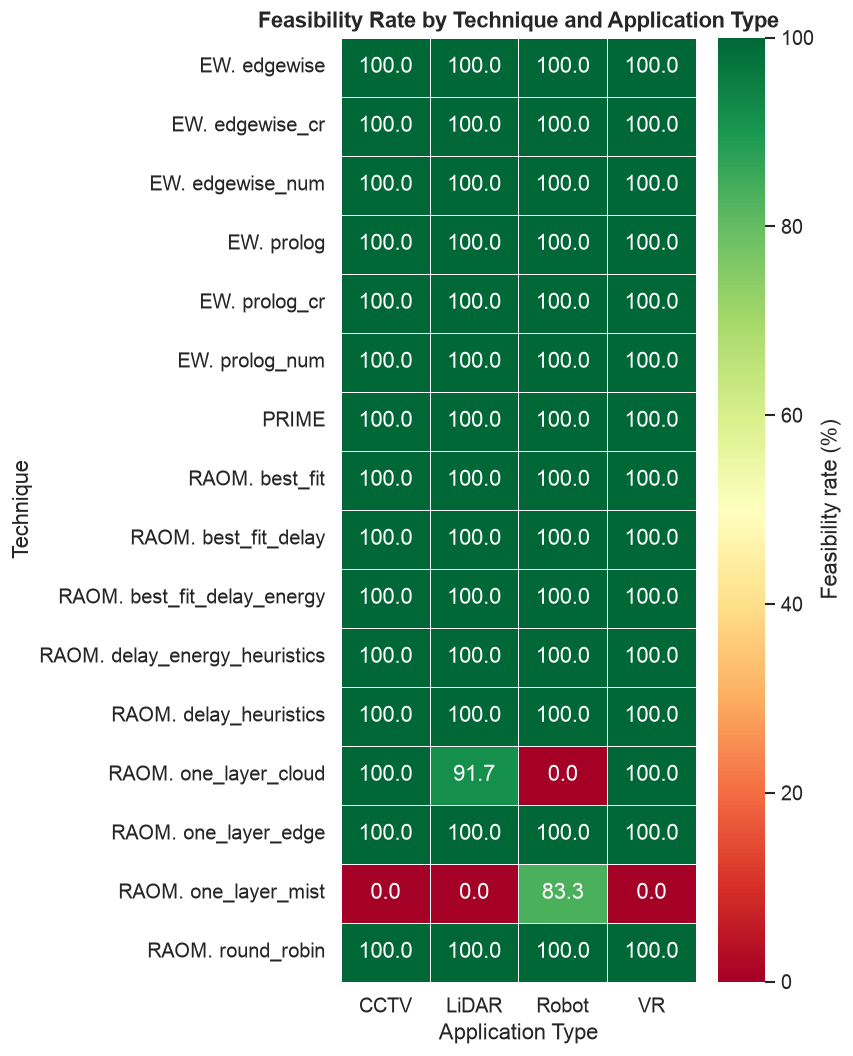

In [4]:
feas_pivot = all_data.groupby(['technique', 'app_name'])['feasible'].mean() * 100
feas_pivot = feas_pivot.unstack('app_name')
feas_pivot = feas_pivot[[APP_NAMES[a] for a in APP_ORDER]]
feas_pivot.index = [short_tech(t) for t in feas_pivot.index]
feas_pivot = feas_pivot.sort_index()

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(feas_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Feasibility rate (%)'},
            linewidths=0.5, linecolor='white')
ax.set_title('Feasibility Rate by Technique and Application Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Application Type')
ax.set_ylabel('Technique')
plt.tight_layout()
plt.savefig('results/figures/feasibility_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Feasibility Bar Charts per Application

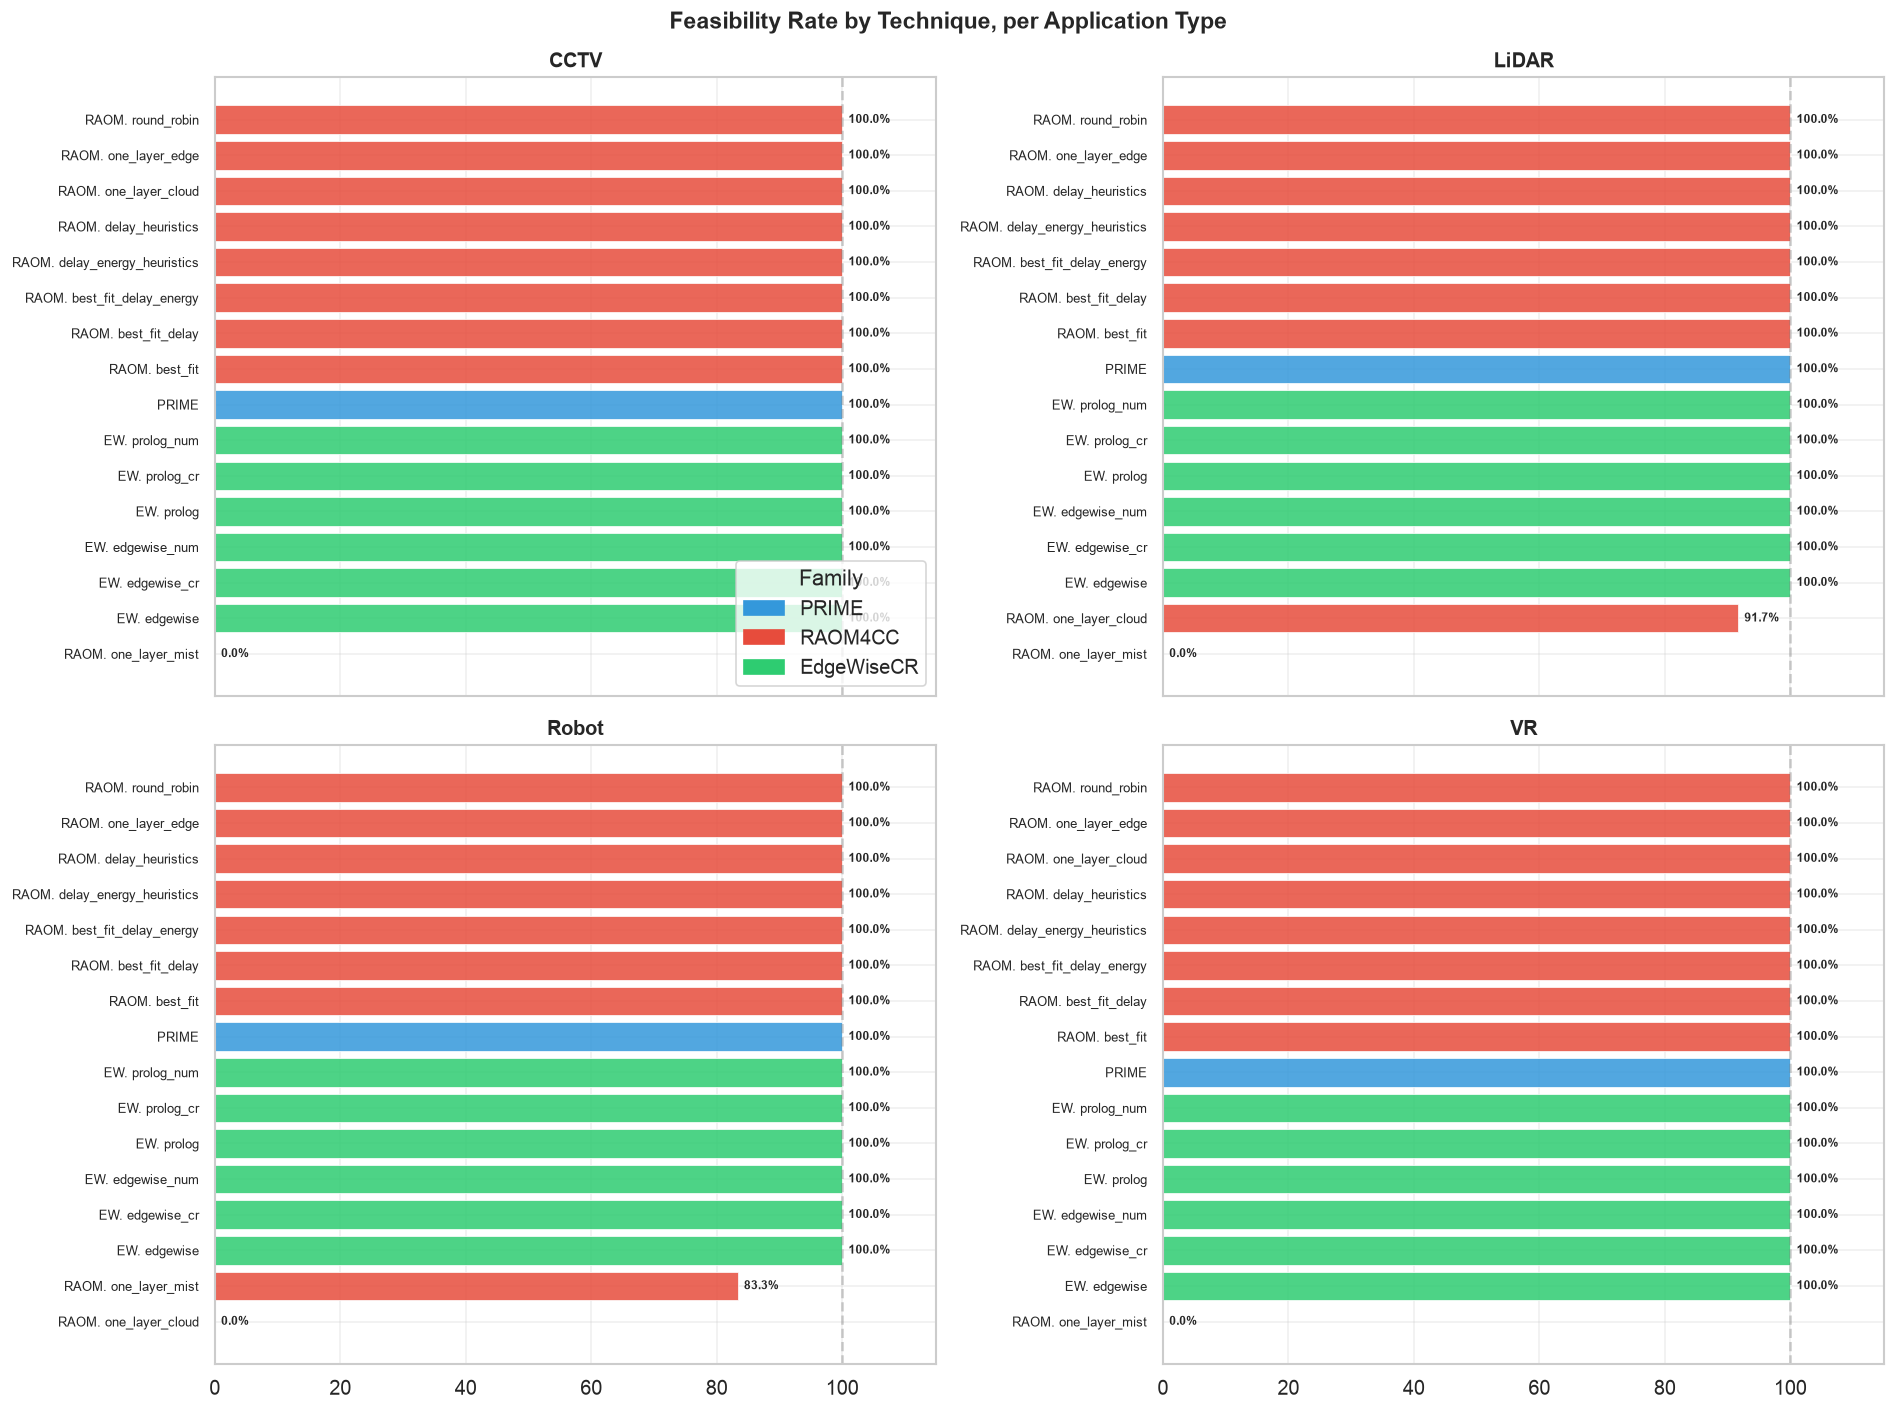

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = all_data[all_data['app'] == app]
    feas = sub.groupby('technique')['feasible'].mean().sort_values() * 100
    colors = [tech_color(t) for t in feas.index]
    ax.barh(range(len(feas)), feas.values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(feas)))
    ax.set_yticklabels([short_tech(t) for t in feas.index], fontsize=8)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    ax.axvline(100, color='grey', ls='--', alpha=0.4)
    ax.set_xlim(0, 115)
    for i, v in enumerate(feas.values):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=7, fontweight='bold')
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Feasibility Rate by Technique, per Application Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/feasibility_faceted.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Execution Time Analysis

PRIME's solver time varies by up to two orders of magnitude across application types,
whereas baseline execution times remain largely app-agnostic. We examine this divergence
through four complementary views.

### 4.1 Execution Time Distribution per Application (median + IQR)

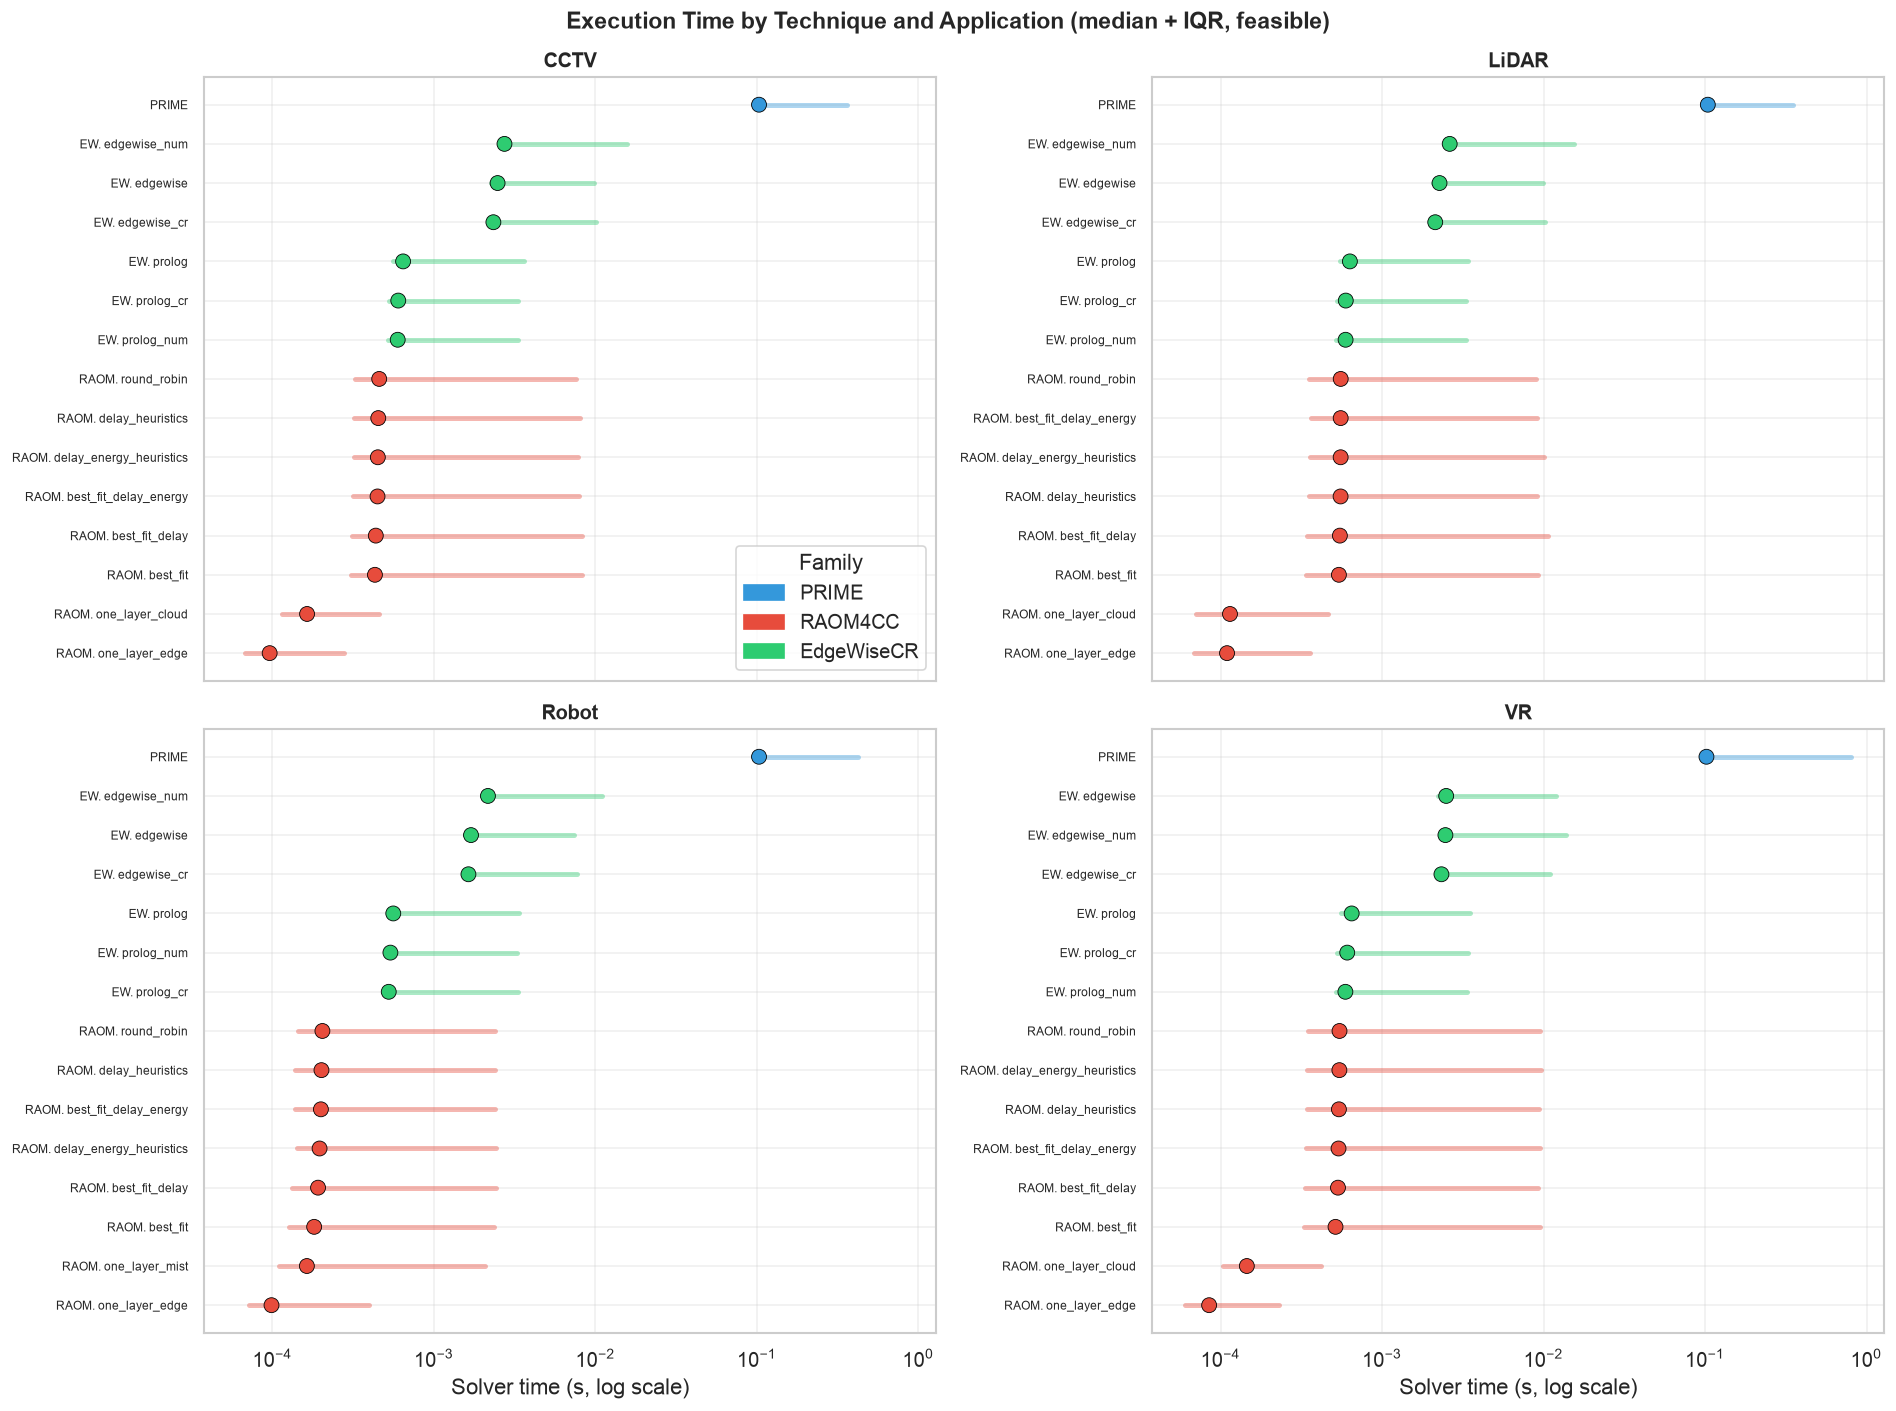

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[feasible_data['app'] == app]
    ts = sub.groupby('technique').agg(
        median=('time_s', 'median'),
        q25=('time_s', lambda x: x.quantile(0.25)),
        q75=('time_s', lambda x: x.quantile(0.75)),
    ).sort_values('median')
    colors = [tech_color(t) for t in ts.index]
    for i, (tech, row) in enumerate(ts.iterrows()):
        ax.plot([row['q25'], row['q75']], [i, i], color=colors[i], linewidth=3, alpha=0.4)
    ax.scatter(ts['median'], range(len(ts)), c=colors, s=80, zorder=5,
               edgecolors='black', linewidth=0.5)
    ax.set_yticks(range(len(ts)))
    ax.set_yticklabels([short_tech(t) for t in ts.index], fontsize=7)
    ax.set_xscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Solver time (s, log scale)')
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Execution Time by Technique and Application (median + IQR, feasible)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/time_distribution_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 PRIME Scalability: Execution Time vs Infrastructure Size

This view corresponds to the key scalability finding: PRIME's solver time grows at
vastly different rates depending on the application. VR is the most computationally
demanding workload (up to ~84 s at 500 nodes), while LiDAR scales best (< 1 s even
at 168 nodes).

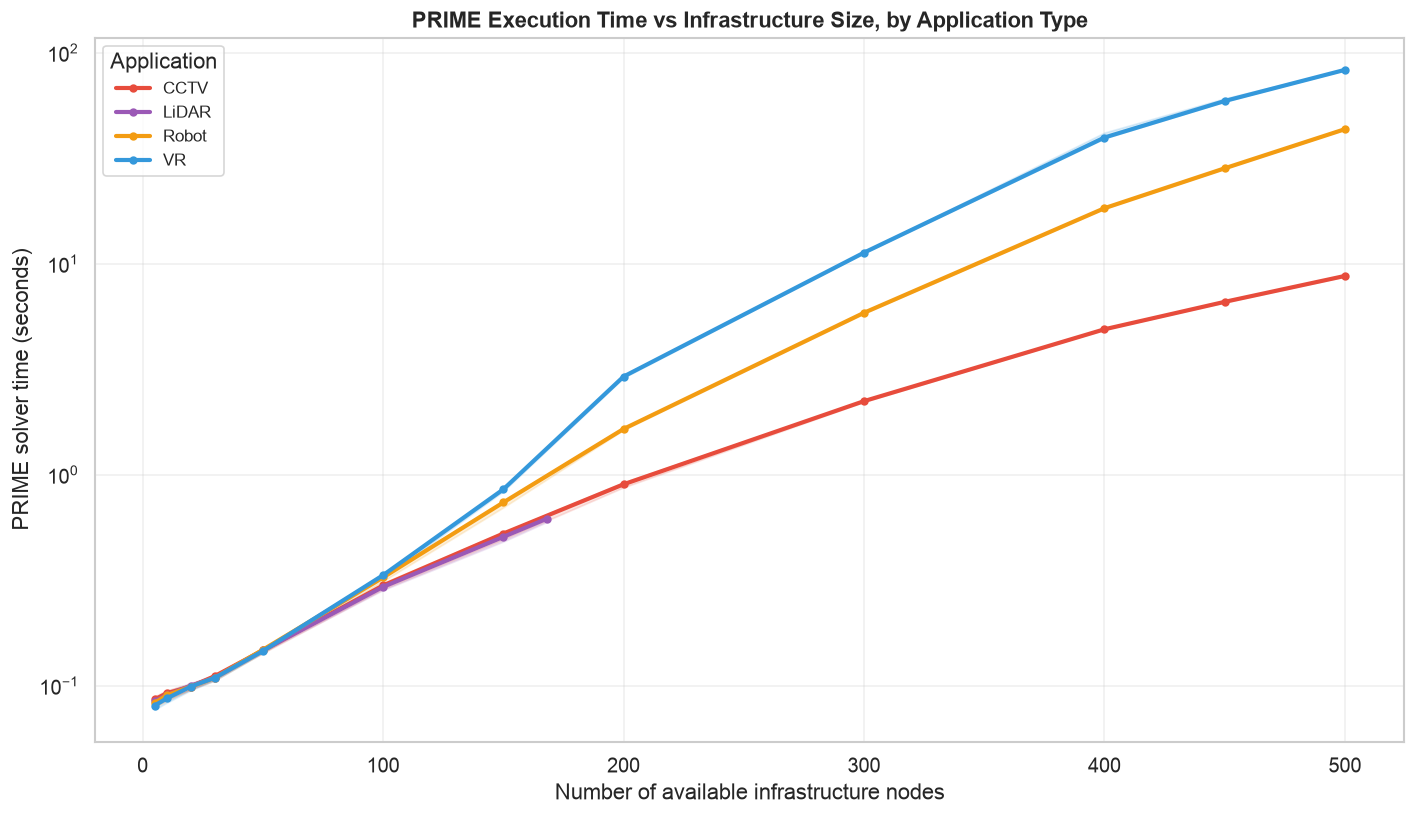

In [7]:
prime_feas = feasible_data[feasible_data['technique'] == 'PRIME'].copy()
prime_agg = prime_feas.groupby(['app', 'num_devices']).agg(
    median_time=('time_s', 'median'),
    q25=('time_s', lambda x: x.quantile(0.25)),
    q75=('time_s', lambda x: x.quantile(0.75)),
    n=('time_s', 'count'),
).reset_index()
# Filter out bins with too few data points
prime_agg = prime_agg[prime_agg['n'] >= 3]

fig, ax = plt.subplots(figsize=(12, 7))
for app in APP_ORDER:
    subset = prime_agg[prime_agg['app'] == app].sort_values('num_devices')
    c = APP_COLORS[app]
    ax.fill_between(subset['num_devices'], subset['q25'], subset['q75'],
                    alpha=0.15, color=c)
    ax.plot(subset['num_devices'], subset['median_time'],
            marker='o', markersize=4, linewidth=2.5, color=c, label=APP_NAMES[app])

ax.set_xlabel('Number of available infrastructure nodes')
ax.set_ylabel('PRIME solver time (seconds)')
ax.set_yscale('log')
ax.set_title('PRIME Execution Time vs Infrastructure Size, by Application Type',
             fontsize=13, fontweight='bold')
ax.legend(title='Application', fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/prime_time_vs_devices_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 All Techniques: Time vs Infrastructure Size per Application

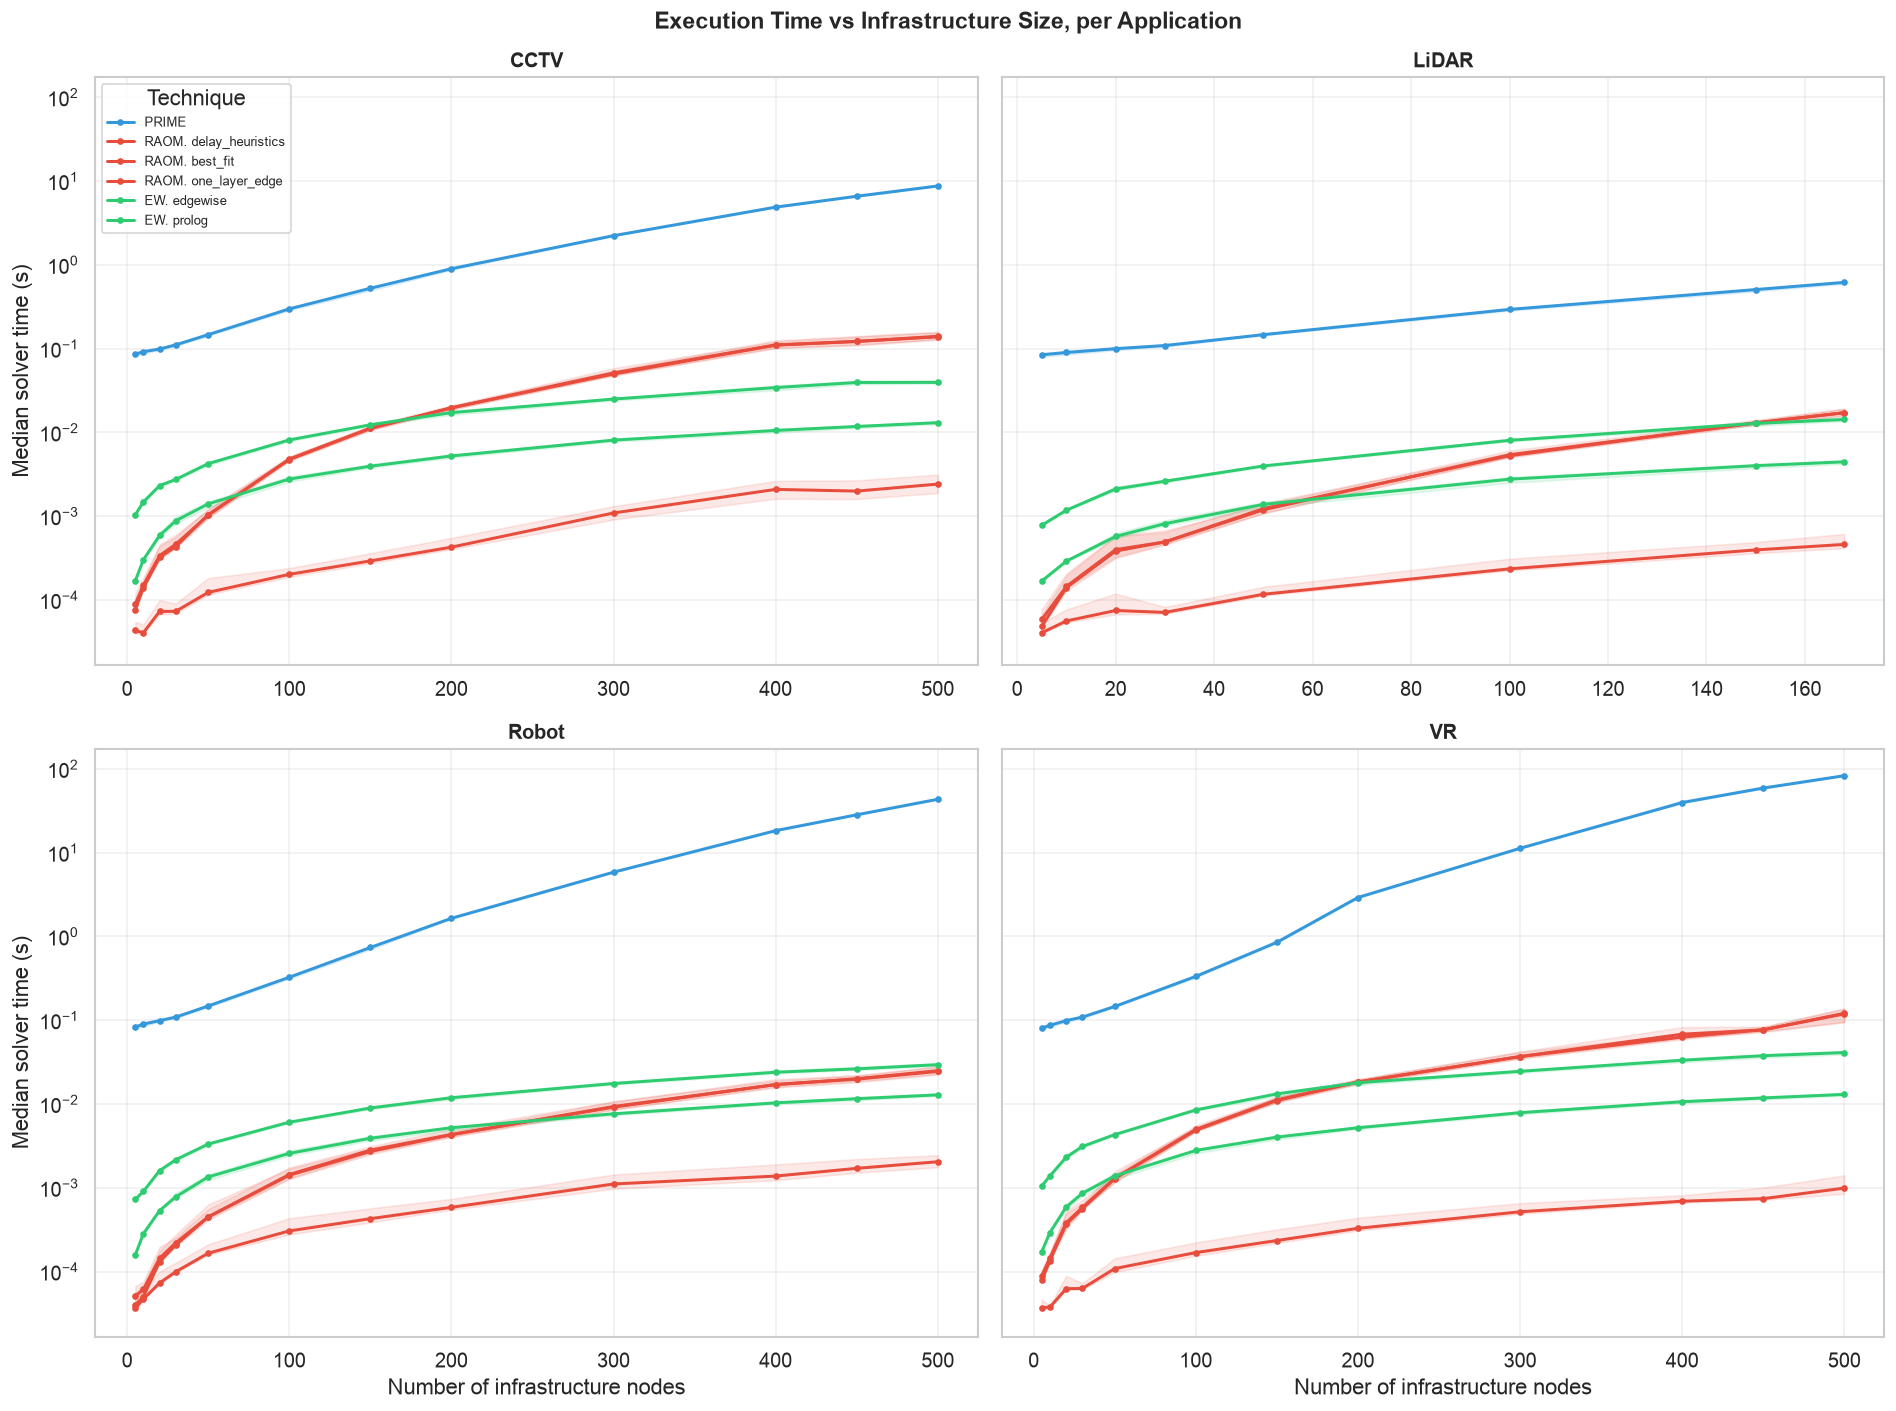

In [8]:
key_techs = ['PRIME', 'RAOM4CC_delay_heuristics', 'RAOM4CC_best_fit',
             'RAOM4CC_one_layer_edge', 'EdgeWiseCR_edgewise', 'EdgeWiseCR_prolog']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[(feasible_data['app'] == app) &
                        (feasible_data['technique'].isin(key_techs))]
    agg = sub.groupby(['technique', 'num_devices']).agg(
        median_time=('time_s', 'median'),
        q25=('time_s', lambda x: x.quantile(0.25)),
        q75=('time_s', lambda x: x.quantile(0.75)),
        n=('time_s', 'count'),
    ).reset_index()
    agg = agg[agg['n'] >= 3]
    for tech in key_techs:
        subset = agg[agg['technique'] == tech].sort_values('num_devices')
        if len(subset) == 0:
            continue
        c = tech_color(tech)
        ax.fill_between(subset['num_devices'], subset['q25'], subset['q75'],
                        alpha=0.12, color=c)
        ax.plot(subset['num_devices'], subset['median_time'],
                marker='o', markersize=3, linewidth=1.8, color=c,
                label=short_tech(tech))
    ax.set_yscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of infrastructure nodes')
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Median solver time (s)')
    if ax == axes[0, 0]:
        ax.legend(title='Technique', fontsize=8, loc='upper left')
fig.suptitle('Execution Time vs Infrastructure Size, per Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/time_vs_devices_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Statistical Tests per Application Type

In [9]:
print('Kruskal-Wallis (all techniques, per app):')
print(f'{"App":<10s} {"H stat":>10s} {"p-value":>14s}')
print('-' * 36)
for app in APP_ORDER:
    sub = feasible_data[feasible_data['app'] == app]
    groups = [g['time_s'].values for _, g in sub.groupby('technique')]
    kw_stat, kw_p = stats.kruskal(*groups)
    print(f'{APP_NAMES[app]:<10s} {kw_stat:>10.2f} {kw_p:>14.2e}')

print(f'\nPairwise Mann-Whitney U (PRIME vs each baseline, per app):')
for app in APP_ORDER:
    sub = feasible_data[feasible_data['app'] == app]
    prime_times = sub[sub['technique'] == 'PRIME']['time_s'].values
    print(f'\n--- {APP_NAMES[app]} ---')
    print(f'{"Baseline":<35s} {"U":>10s} {"p":>12s} {"r":>8s}')
    print('-' * 67)
    for tech in sorted(sub['technique'].unique()):
        if tech == 'PRIME':
            continue
        tt = sub[sub['technique'] == tech]['time_s'].values
        if len(tt) == 0:
            print(f'{tech:<35s} {"N/A":>10s}')
            continue
        u, p = stats.mannwhitneyu(prime_times, tt, alternative='two-sided')
        z = stats.norm.ppf(1 - p / 2)
        r = abs(z) / np.sqrt(len(prime_times) + len(tt))
        print(f'{tech:<35s} {u:>10.0f} {p:>12.2e} {r:>8.3f}')

Kruskal-Wallis (all techniques, per app):
App            H stat        p-value
------------------------------------
CCTV         14881.39       0.00e+00
LiDAR        16733.54       0.00e+00
Robot        14910.29       0.00e+00
VR           16161.66       0.00e+00

Pairwise Mann-Whitney U (PRIME vs each baseline, per app):

--- CCTV ---
Baseline                                     U            p        r
-------------------------------------------------------------------
EdgeWiseCR_edgewise                    5760000     0.00e+00      inf
EdgeWiseCR_edgewise_cr                 5760000     0.00e+00      inf
EdgeWiseCR_edgewise_num                5760000     0.00e+00      inf
EdgeWiseCR_prolog                      5760000     0.00e+00      inf
EdgeWiseCR_prolog_cr                   5760000     0.00e+00      inf
EdgeWiseCR_prolog_num                  5760000     0.00e+00      inf
RAOM4CC_best_fit                       5318595     0.00e+00      inf
RAOM4CC_best_fit_delay                 533

RAOM4CC_round_robin                    5607700     0.00e+00      inf


### 4.5 Execution Time by Scenario Scale, per Application

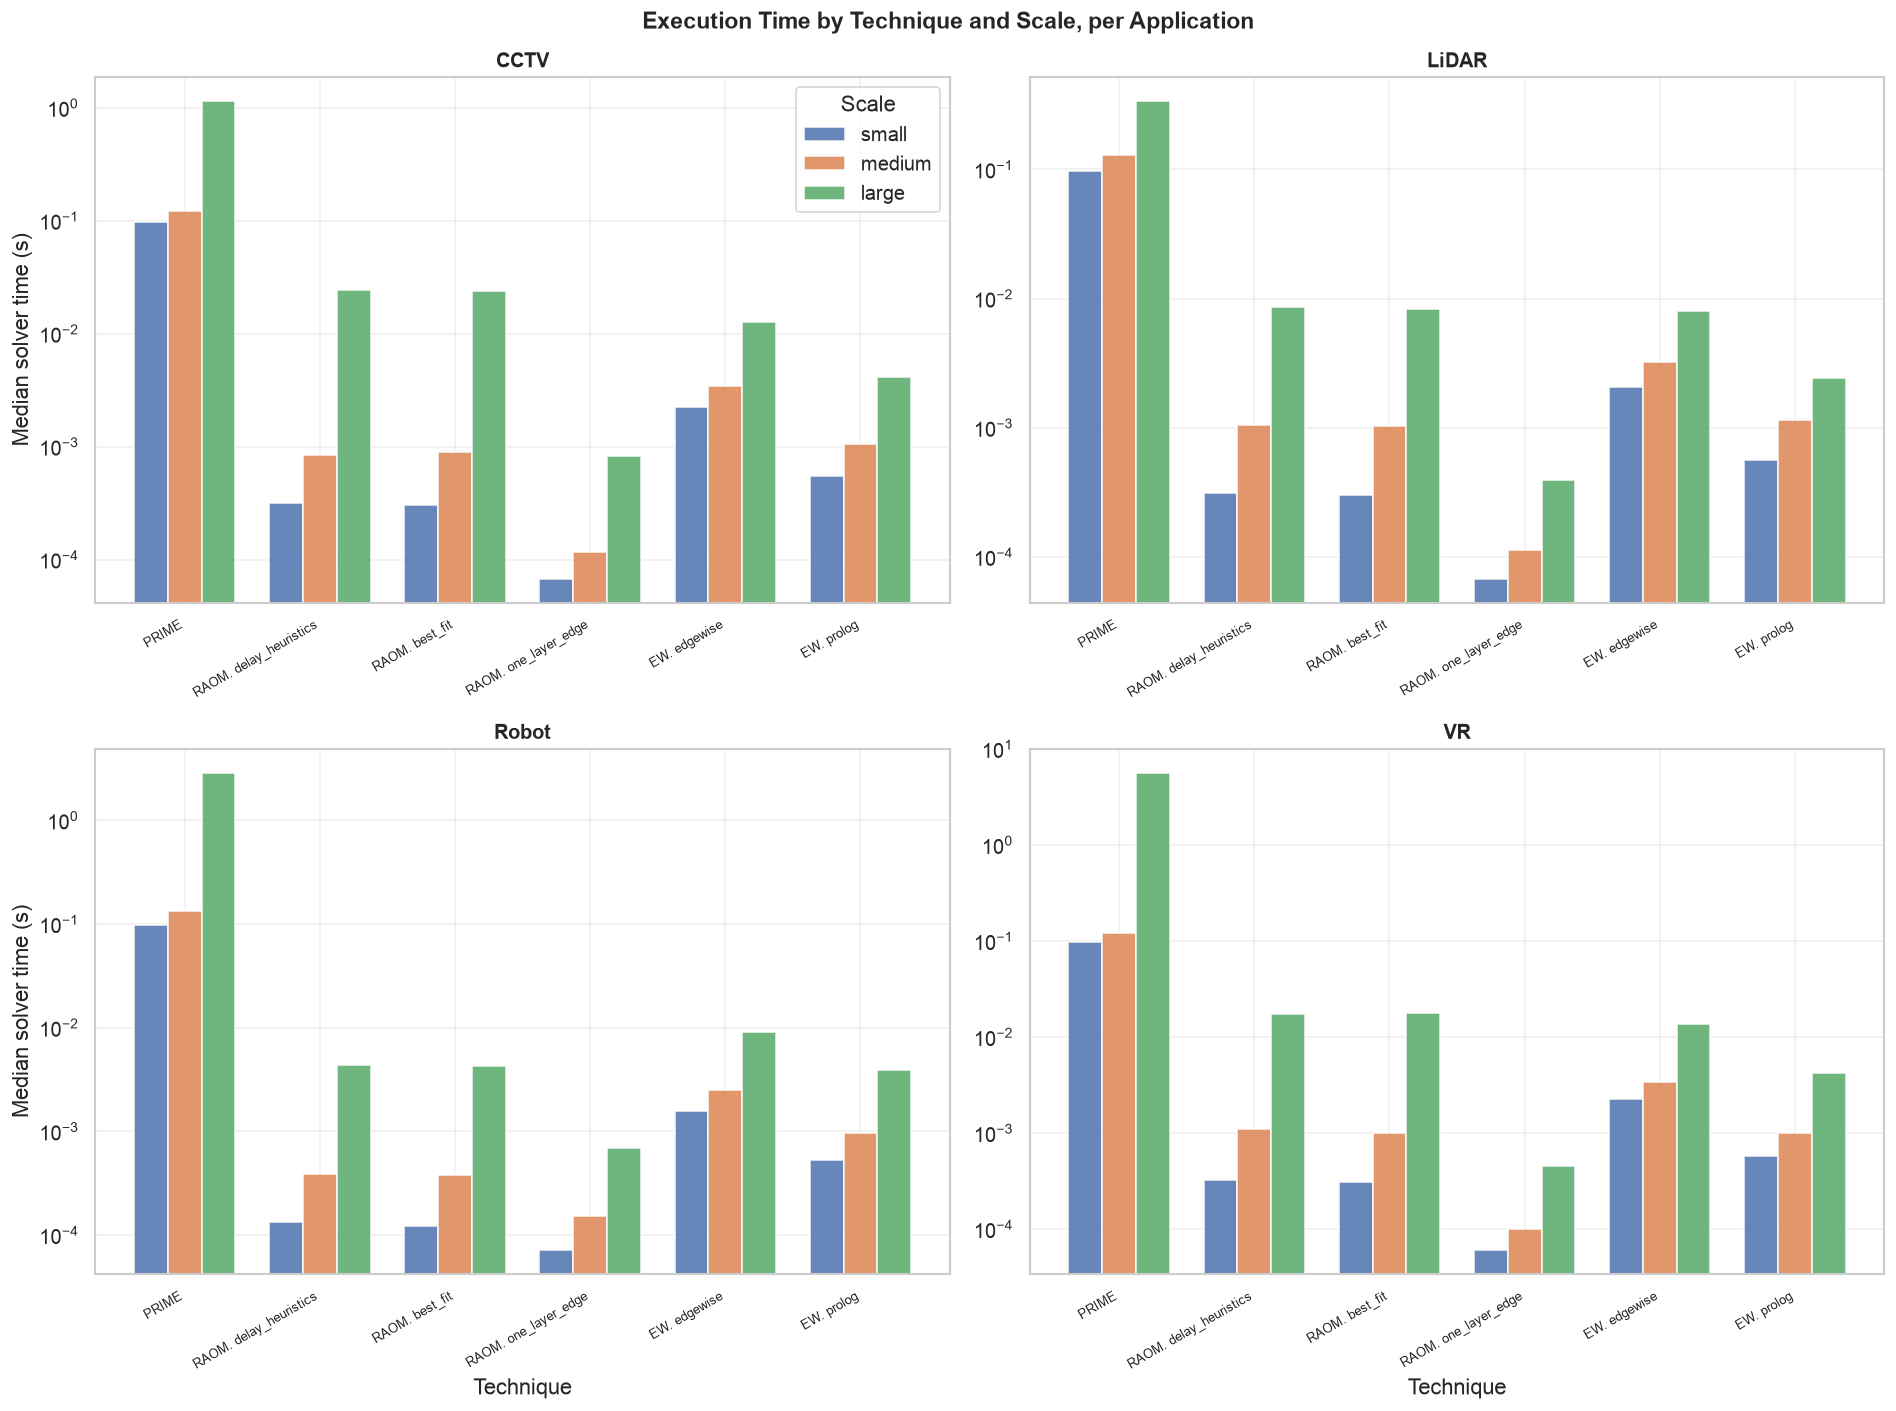

In [10]:
scale_order = ['small', 'medium', 'large']
key_techs_scale = ['PRIME', 'RAOM4CC_delay_heuristics', 'RAOM4CC_best_fit',
                   'RAOM4CC_one_layer_edge', 'EdgeWiseCR_edgewise', 'EdgeWiseCR_prolog']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[(feasible_data['app'] == app) &
                        (feasible_data['technique'].isin(key_techs_scale))]
    st = sub.groupby(['technique', 'scale'])['time_s'].median().unstack('scale')
    st = st.reindex(columns=scale_order)
    st = st.loc[[t for t in key_techs_scale if t in st.index]]
    x = np.arange(len(st))
    width = 0.25
    for i, scale in enumerate(scale_order):
        ax.bar(x + i * width, st[scale].values, width, label=scale, alpha=0.85, edgecolor='white')
    ax.set_xticks(x + width)
    ax.set_xticklabels([short_tech(t) for t in st.index], rotation=30, ha='right', fontsize=8)
    ax.set_yscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Technique')
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Median solver time (s)')
    if ax == axes[0, 0]:
        ax.legend(title='Scale')
fig.suptitle('Execution Time by Technique and Scale, per Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/time_by_scale_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Node Selection Analysis

The number of nodes selected by each technique varies modestly by application type.
PRIME and EdgeWiseCR MILP select more nodes for VR and CCTV (higher resource demands),
while greedy heuristics consistently select a single node regardless of workload.

### 5.1 Median Node Count Heatmap (Technique × Application)

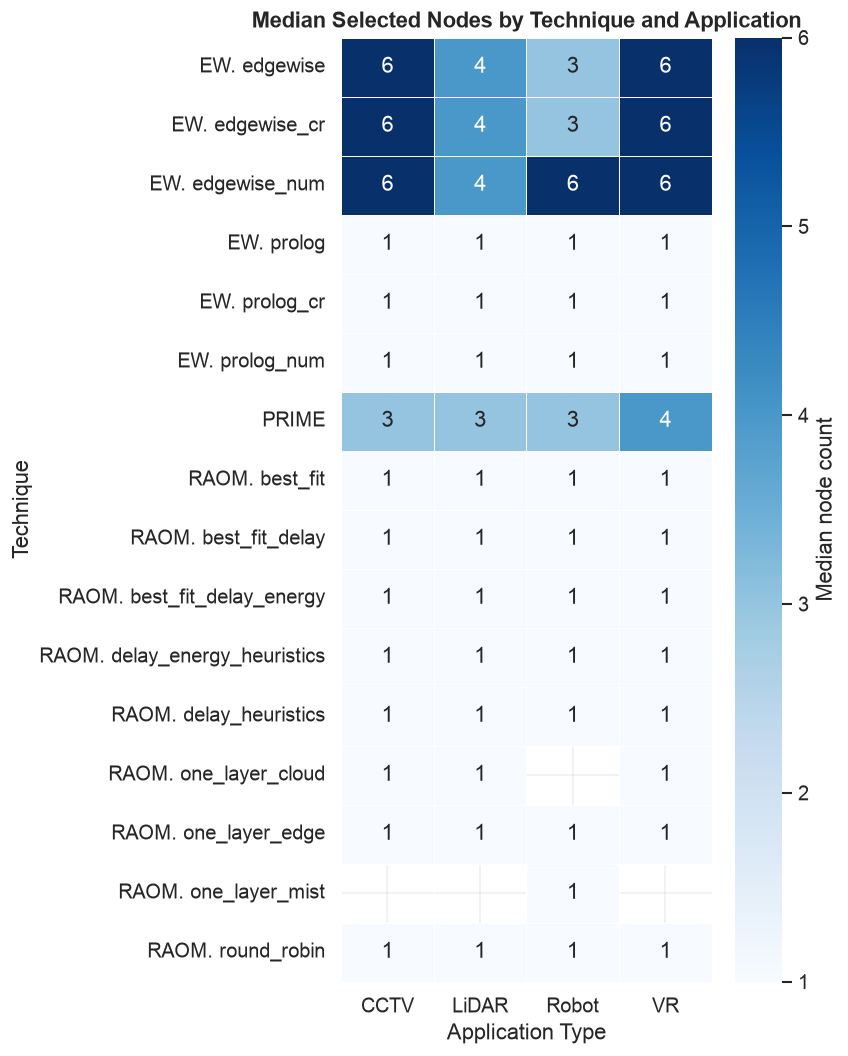

In [11]:
nodes_pivot = (feasible_data.groupby(['technique', 'app_name'])['nodes'].median()
               .unstack('app_name'))
nodes_pivot = nodes_pivot[[APP_NAMES[a] for a in APP_ORDER]]
nodes_pivot.index = [short_tech(t) for t in nodes_pivot.index]
nodes_pivot = nodes_pivot.sort_index()

fig, ax = plt.subplots(figsize=(7, 9))
sns.heatmap(nodes_pivot, annot=True, fmt='.0f', cmap='Blues',
            ax=ax, cbar_kws={'label': 'Median node count'},
            linewidths=0.5, linecolor='white')
ax.set_title('Median Selected Nodes by Technique and Application', fontsize=13, fontweight='bold')
ax.set_xlabel('Application Type')
ax.set_ylabel('Technique')
plt.tight_layout()
plt.savefig('results/figures/nodes_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Node Count Distribution per Application (median + IQR)

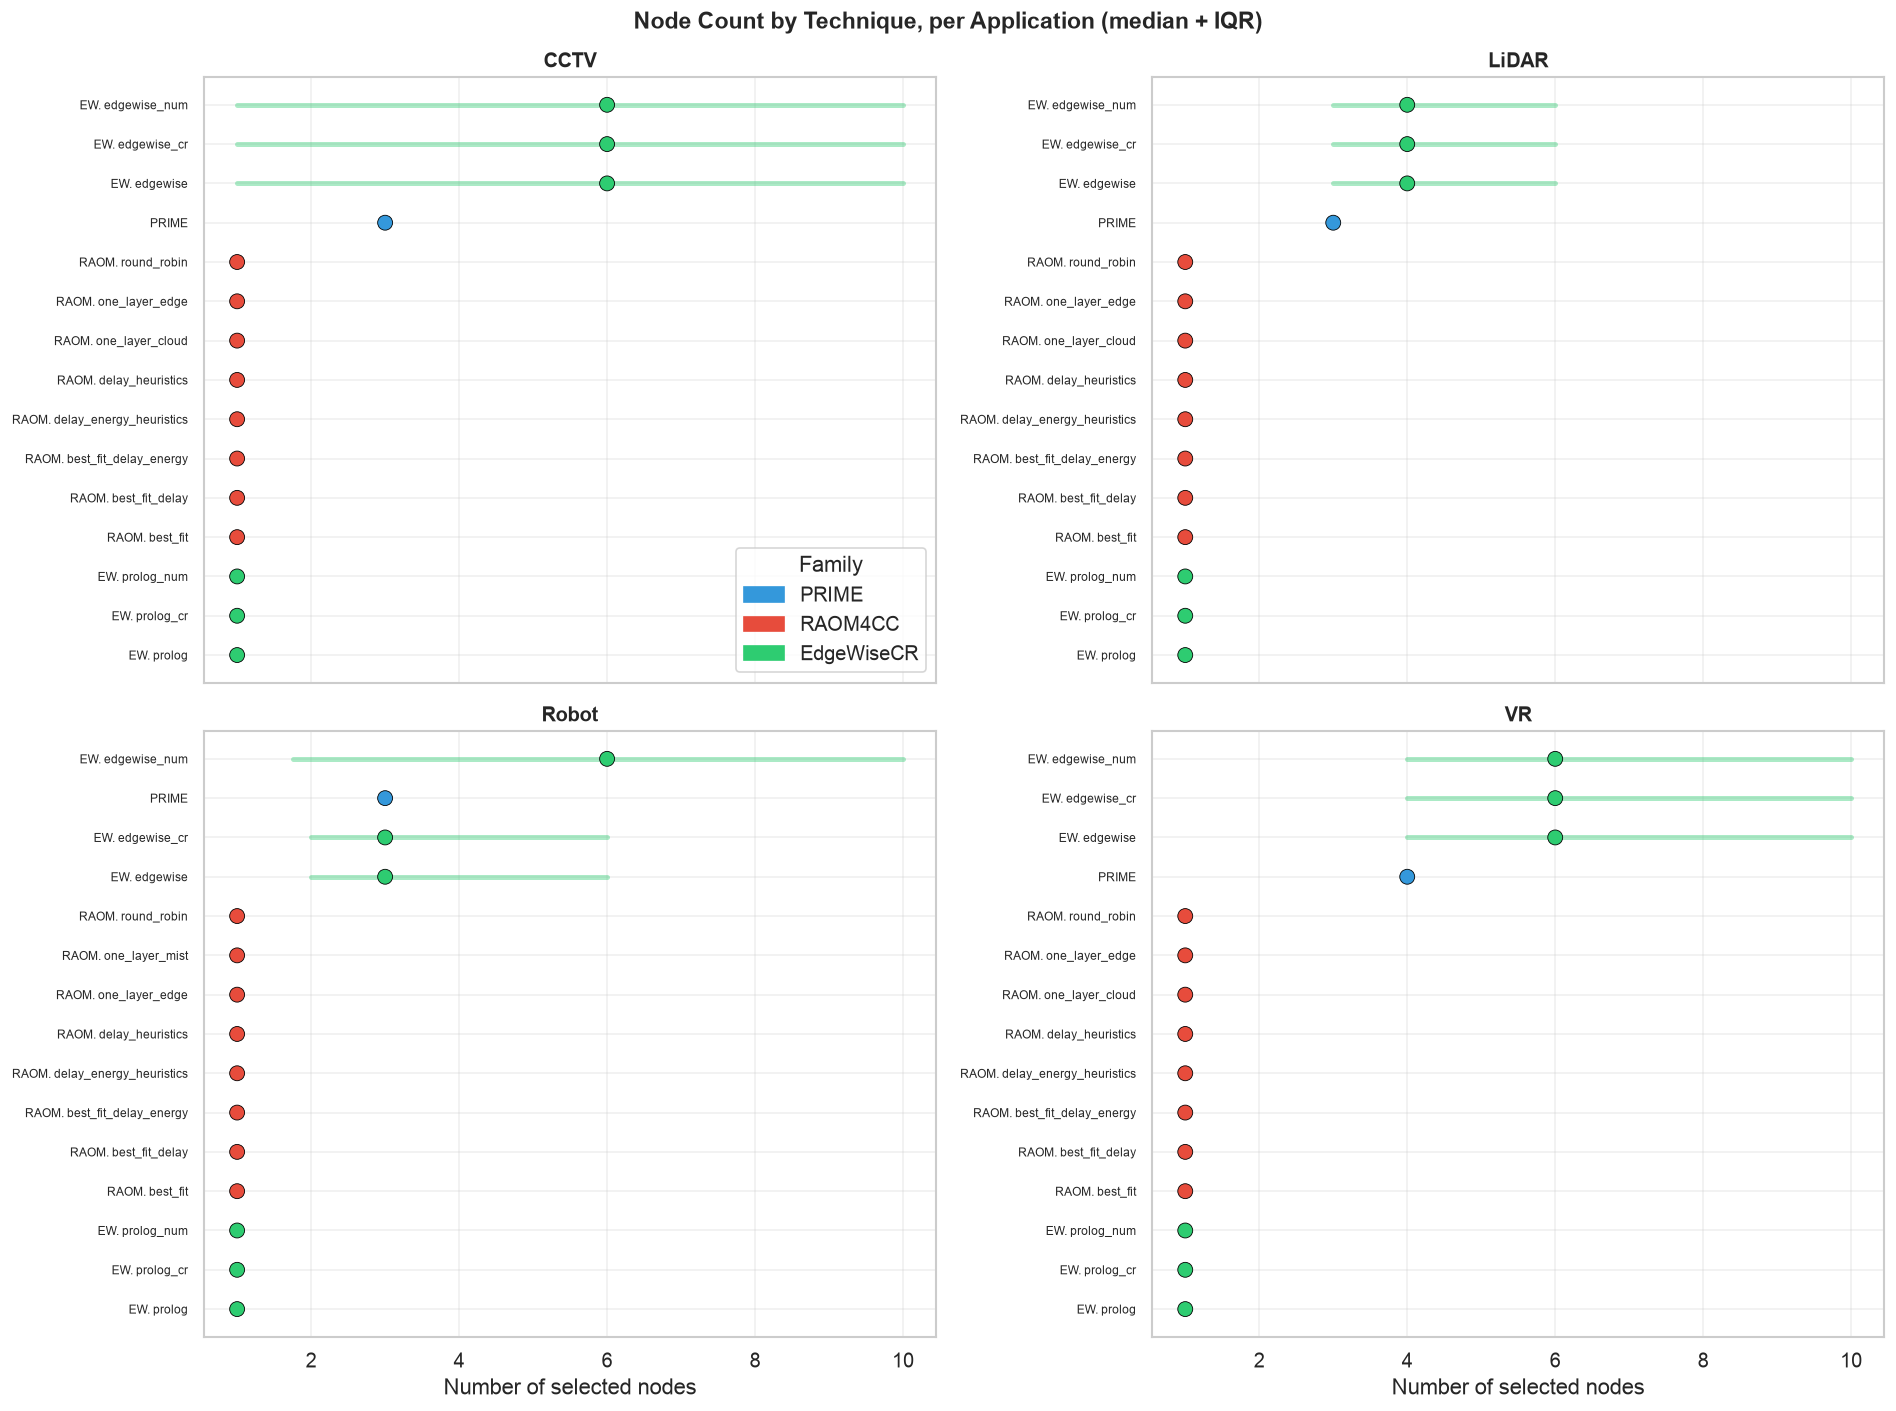

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[feasible_data['app'] == app]
    ns = sub.groupby('technique').agg(
        median=('nodes', 'median'),
        q25=('nodes', lambda x: x.quantile(0.25)),
        q75=('nodes', lambda x: x.quantile(0.75)),
    ).sort_values('median')
    colors = [tech_color(t) for t in ns.index]
    for i, (tech, row) in enumerate(ns.iterrows()):
        ax.plot([row['q25'], row['q75']], [i, i], color=colors[i], linewidth=3, alpha=0.4)
    ax.scatter(ns['median'], range(len(ns)), c=colors, s=80, zorder=5,
               edgecolors='black', linewidth=0.5)
    ax.set_yticks(range(len(ns)))
    ax.set_yticklabels([short_tech(t) for t in ns.index], fontsize=7)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of selected nodes')
    if ax == axes[0, 0]:
        patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
        ax.legend(handles=patches, loc='lower right', title='Family')
fig.suptitle('Node Count by Technique, per Application (median + IQR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/nodes_distribution_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Cost Analysis

The raw cost figures are not directly comparable across techniques because the baselines
ignore 6 of 12 hard constraint types. We report them here to expose the structural
mechanism by which the baselines achieve their apparent cost advantage: constraint
relaxation, single-node selection, and a simplified pricing model.


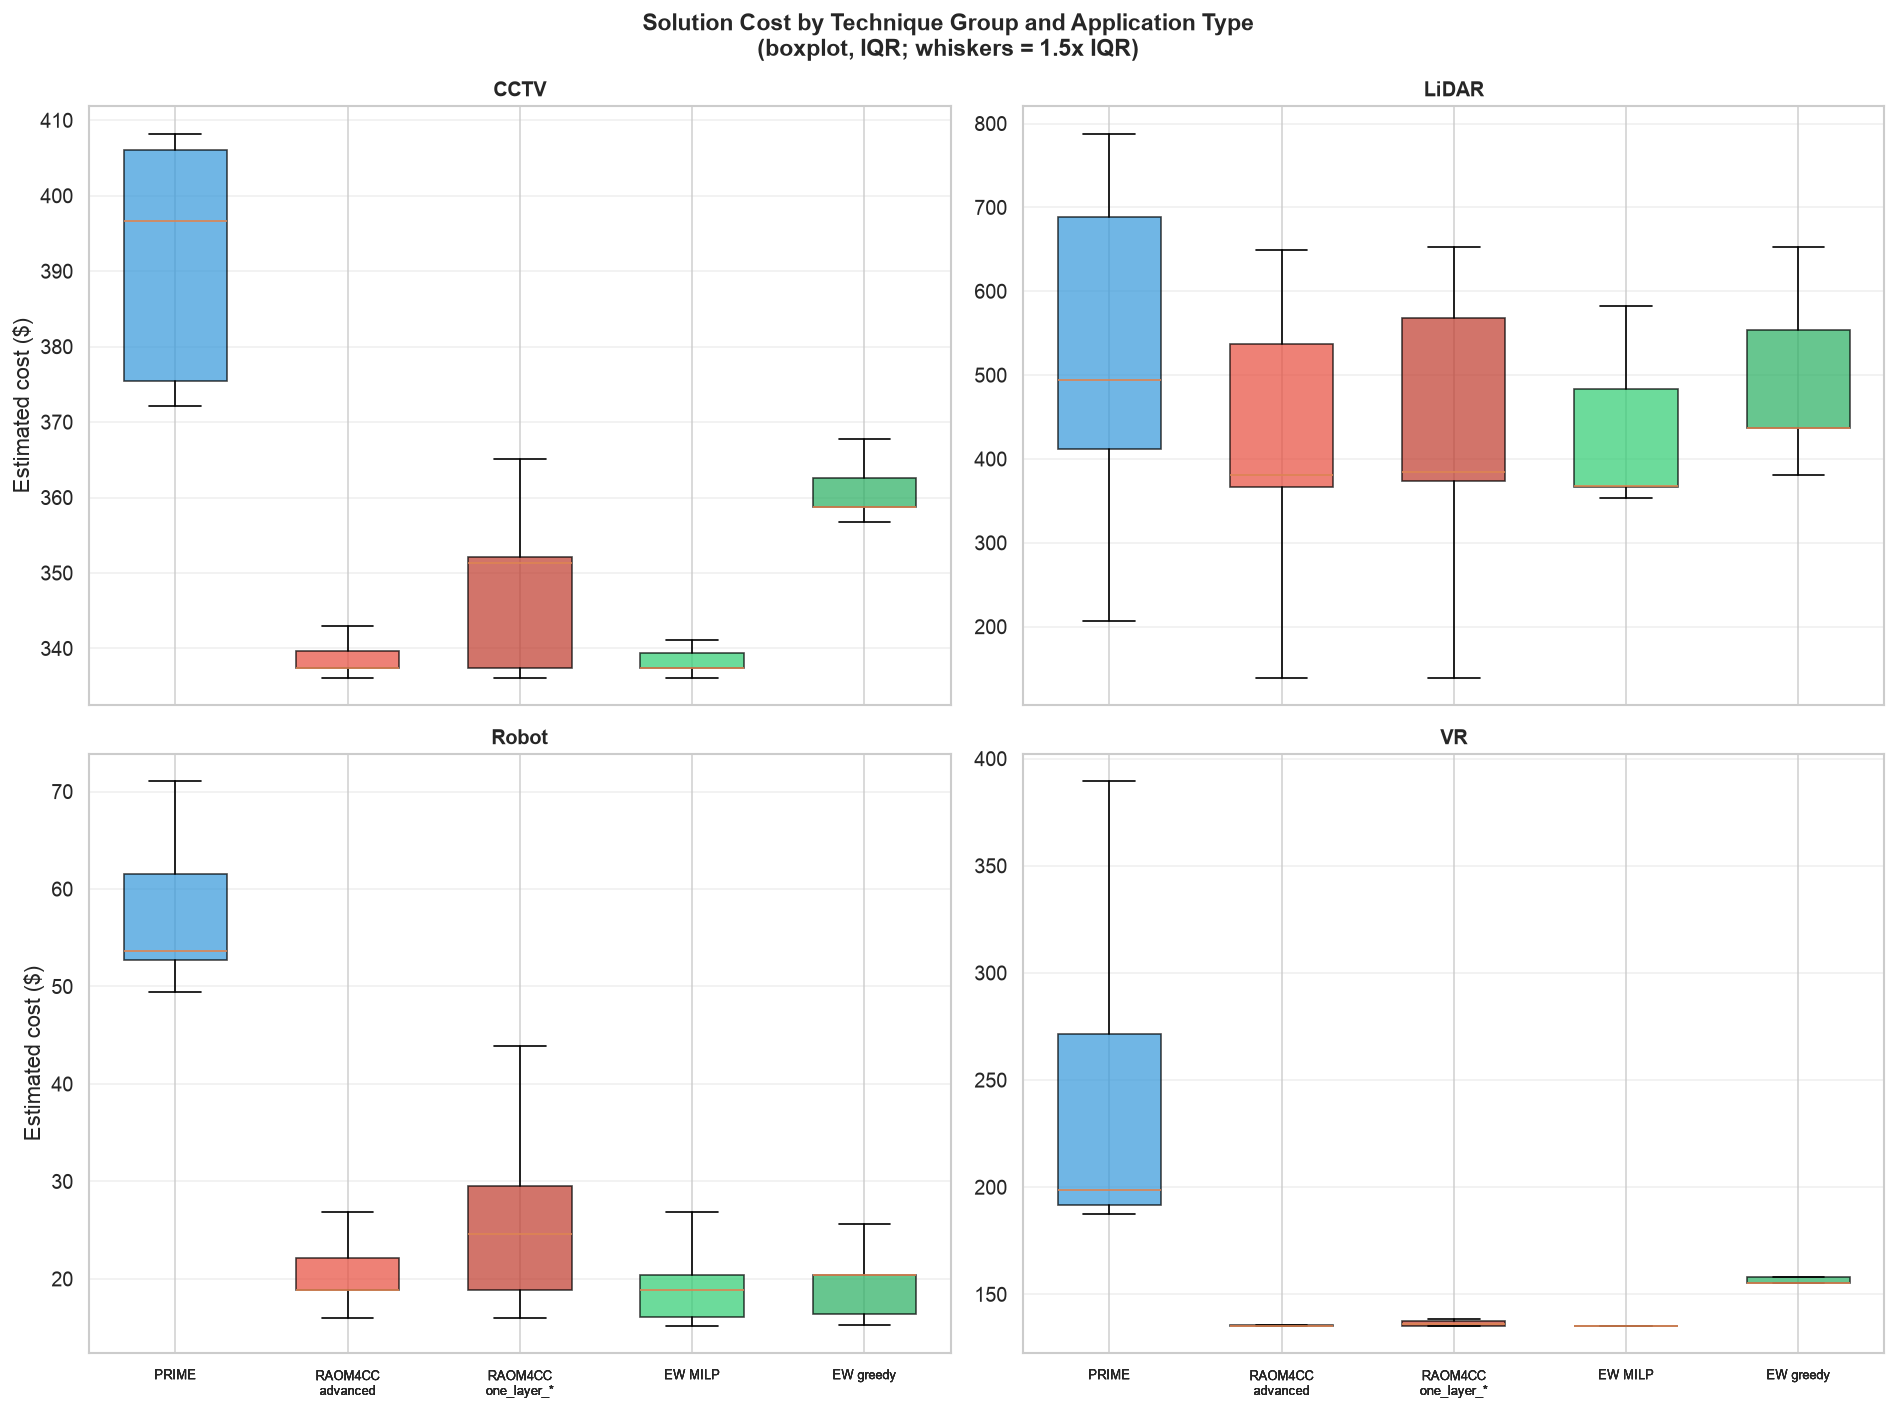

Median cost ($) by group and app:
                       CCTV   LiDAR  Robot      VR
group                                             
PRIME                396.67  493.91  53.62  198.70
RAOM4CC advanced     337.35  381.20  18.90  135.15
RAOM4CC one_layer_*  351.38  384.56  24.57  136.20
EdgeWiseCR MILP      337.35  367.31  18.87  135.15
EdgeWiseCR greedy    358.78  437.31  20.43  155.26


In [13]:
# --- Build unified cost dataframe ---
prime_raw['cost_num'] = prime_raw['cost'].astype(str).str.replace(' $', '').astype(float)
raom_raw['cost_num'] = raom_raw['estimated_cost'].astype(float)
ew_raw['cost_num'] = ew_raw['estimated_cost'].astype(float)

def raom_cost_group(alg):
    if 'one_layer' in alg: return 'RAOM4CC one_layer_*'
    return 'RAOM4CC advanced'
def ew_cost_group(alg):
    if 'prolog' in alg: return 'EdgeWiseCR greedy'
    return 'EdgeWiseCR MILP'

rows = []
for _, r in prime_raw[prime_raw['status'] == 'COMPLETED'].iterrows():
    rows.append({'app': r['scenario_id'].split('_')[2], 'group': 'PRIME',
                 'cost': r['cost_num'],
                 'nodes': len(ast.literal_eval(r['add_ons'])) if pd.notna(r['add_ons']) else 0})
for _, r in raom_raw[raom_raw['feasible'].astype(str) == 'True'].iterrows():
    rows.append({'app': r['scenario_id'].split('_')[2], 'group': raom_cost_group(r['algorithm']),
                 'cost': r['cost_num'],
                 'nodes': len(ast.literal_eval(r['selected_node'])) if pd.notna(r['selected_node']) else 0})
for _, r in ew_raw[ew_raw['feasible'].astype(str) == 'True'].iterrows():
    rows.append({'app': r['scenario_id'].split('_')[2], 'group': ew_cost_group(r['algorithm']),
                 'cost': r['cost_num'], 'nodes': r['bins']})

cost_df = pd.DataFrame(rows)
GROUP_ORDER = ['PRIME', 'RAOM4CC advanced', 'RAOM4CC one_layer_*',
               'EdgeWiseCR MILP', 'EdgeWiseCR greedy']
GROUP_COLORS = {'PRIME': '#3498db', 'RAOM4CC advanced': '#e74c3c',
                'RAOM4CC one_layer_*': '#c0392b',
                'EdgeWiseCR MILP': '#2ecc71', 'EdgeWiseCR greedy': '#27ae60'}
GROUP_LABELS = ['PRIME', 'RAOM4CC\nadvanced', 'RAOM4CC\none_layer_*',
                'EW MILP', 'EW greedy']

# Boxplot: cost by group, faceted by app
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = cost_df[cost_df['app'] == app]
    box_data = [sub[sub['group'] == g]['cost'].values for g in GROUP_ORDER]
    bp = ax.boxplot(box_data, tick_labels=GROUP_LABELS,
                    patch_artist=True, showfliers=False, widths=0.6)
    for patch, g in zip(bp['boxes'], GROUP_ORDER):
        patch.set_facecolor(GROUP_COLORS[g])
        patch.set_alpha(0.7)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Estimated cost ($)')
    ax.tick_params(axis='x', labelsize=8)
fig.suptitle('Solution Cost by Technique Group and Application Type\n(boxplot, IQR; whiskers = 1.5x IQR)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/cost_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

# Print median cost table
med = cost_df.groupby(['group', 'app'])['cost'].median().unstack('app')
med = med.reindex(index=GROUP_ORDER)[APP_ORDER]
med.columns = [APP_NAMES[a] for a in APP_ORDER]
print('Median cost ($) by group and app:')
print(med.round(2).to_string())


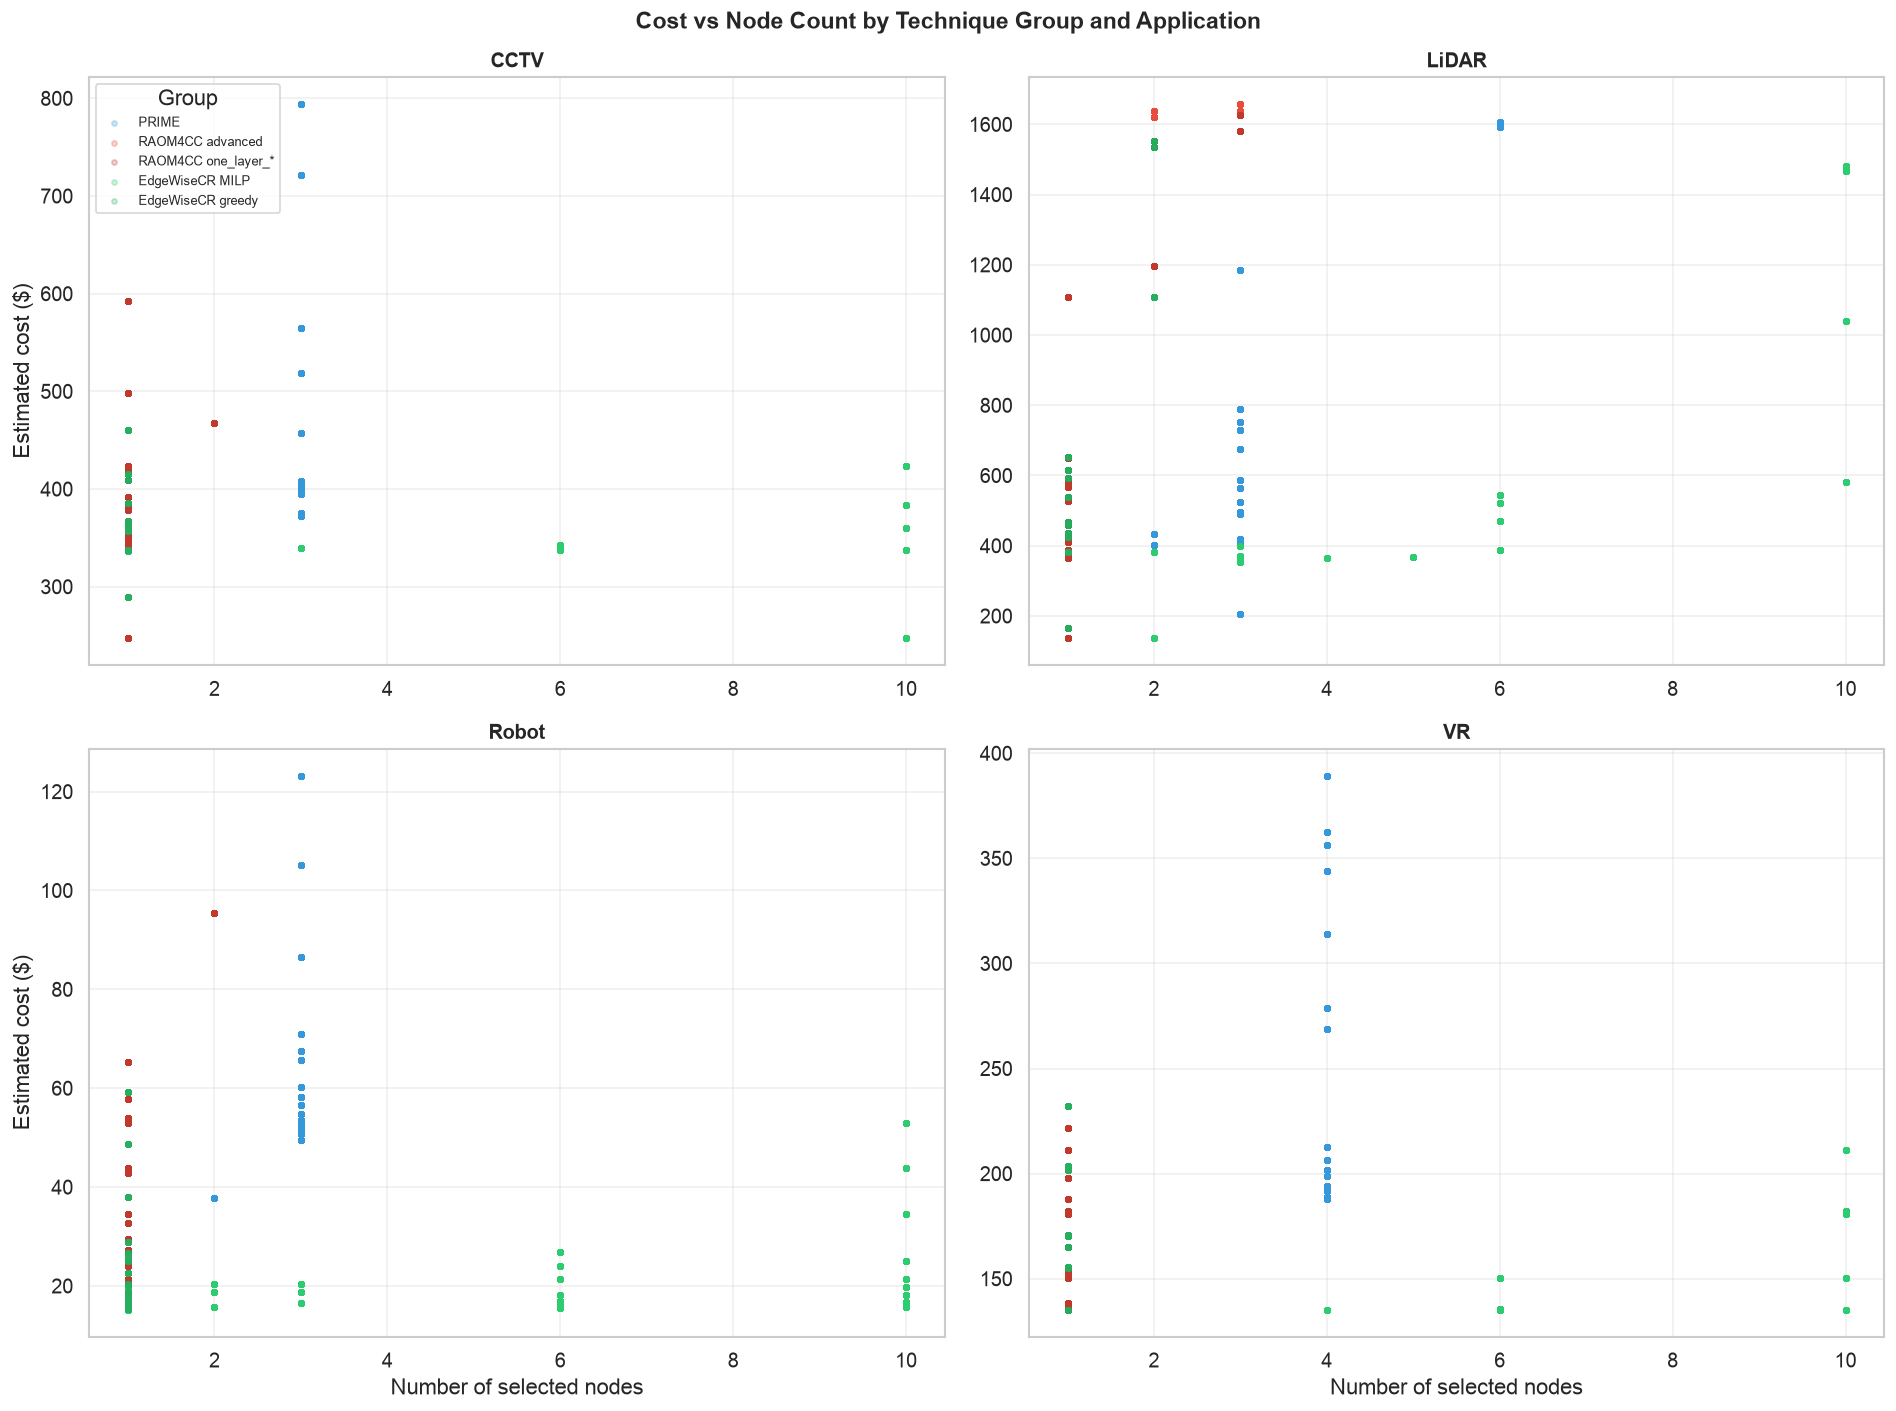

In [14]:
# Cost vs node count scatter, faceted by app
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, app in zip(axes.flat, APP_ORDER):
    sub = cost_df[cost_df['app'] == app]
    for g in GROUP_ORDER:
        gsub = sub[sub['group'] == g]
        if len(gsub) == 0:
            continue
        ax.scatter(gsub['nodes'], gsub['cost'], c=GROUP_COLORS[g], alpha=0.25, s=10, label=g)
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Number of selected nodes')
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Estimated cost ($)')
    if ax == axes[0, 0]:
        ax.legend(title='Group', fontsize=8, loc='upper left')
fig.suptitle('Cost vs Node Count by Technique Group and Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/cost_vs_nodes_by_app.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
# Cost comparability analysis
print('=' * 80)
print('COST ANALYSIS SUMMARY')
print('=' * 80)
print()
print('PRIME reports the highest median cost on every application because it enforces')
print('12 hard constraint types (vs 6 in baselines) and selects 3-4 nodes (vs 1 in')
print('single-node baselines). The cost difference is the price of deployability.')
print()
print('Median cost ratio (baseline / PRIME):')
for app in APP_ORDER:
    p_cost = cost_df[(cost_df['app'] == app) & (cost_df['group'] == 'PRIME')]['cost'].median()
    sn = cost_df[(cost_df['app'] == app) & (cost_df['group'].isin(['RAOM4CC advanced', 'EdgeWiseCR greedy']))]['cost'].median()
    print(f'  {APP_NAMES[app]:<8s}: single-node baselines = {sn/p_cost:.1%} of PRIME cost')
print()
print('Conclusion: costs are NOT comparable. Baselines solve a relaxed problem.')
print('PRIME\'s higher cost reflects the true cost of a deployable solution.')


COST ANALYSIS SUMMARY

PRIME reports the highest median cost on every application because it enforces
12 hard constraint types (vs 6 in baselines) and selects 3-4 nodes (vs 1 in
single-node baselines). The cost difference is the price of deployability.

Median cost ratio (baseline / PRIME):
  CCTV    : single-node baselines = 85.3% of PRIME cost
  LiDAR   : single-node baselines = 83.6% of PRIME cost
  Robot   : single-node baselines = 35.2% of PRIME cost
  VR      : single-node baselines = 68.1% of PRIME cost

Conclusion: costs are NOT comparable. Baselines solve a relaxed problem.
PRIME's higher cost reflects the true cost of a deployable solution.


## 7. Pareto Front: Execution Time vs Constraint Coverage

Each technique is evaluated on two dimensions:
- **X-axis:** Median execution time (lower = better)
- **Y-axis:** Constraint types supported (higher = more complete solution)

PRIME supports 12/12 constraint types; baselines support 6/12. The Pareto front
shifts rightward for PRIME on VR and Robot (higher solver time), while remaining
near-static for baselines across all apps.

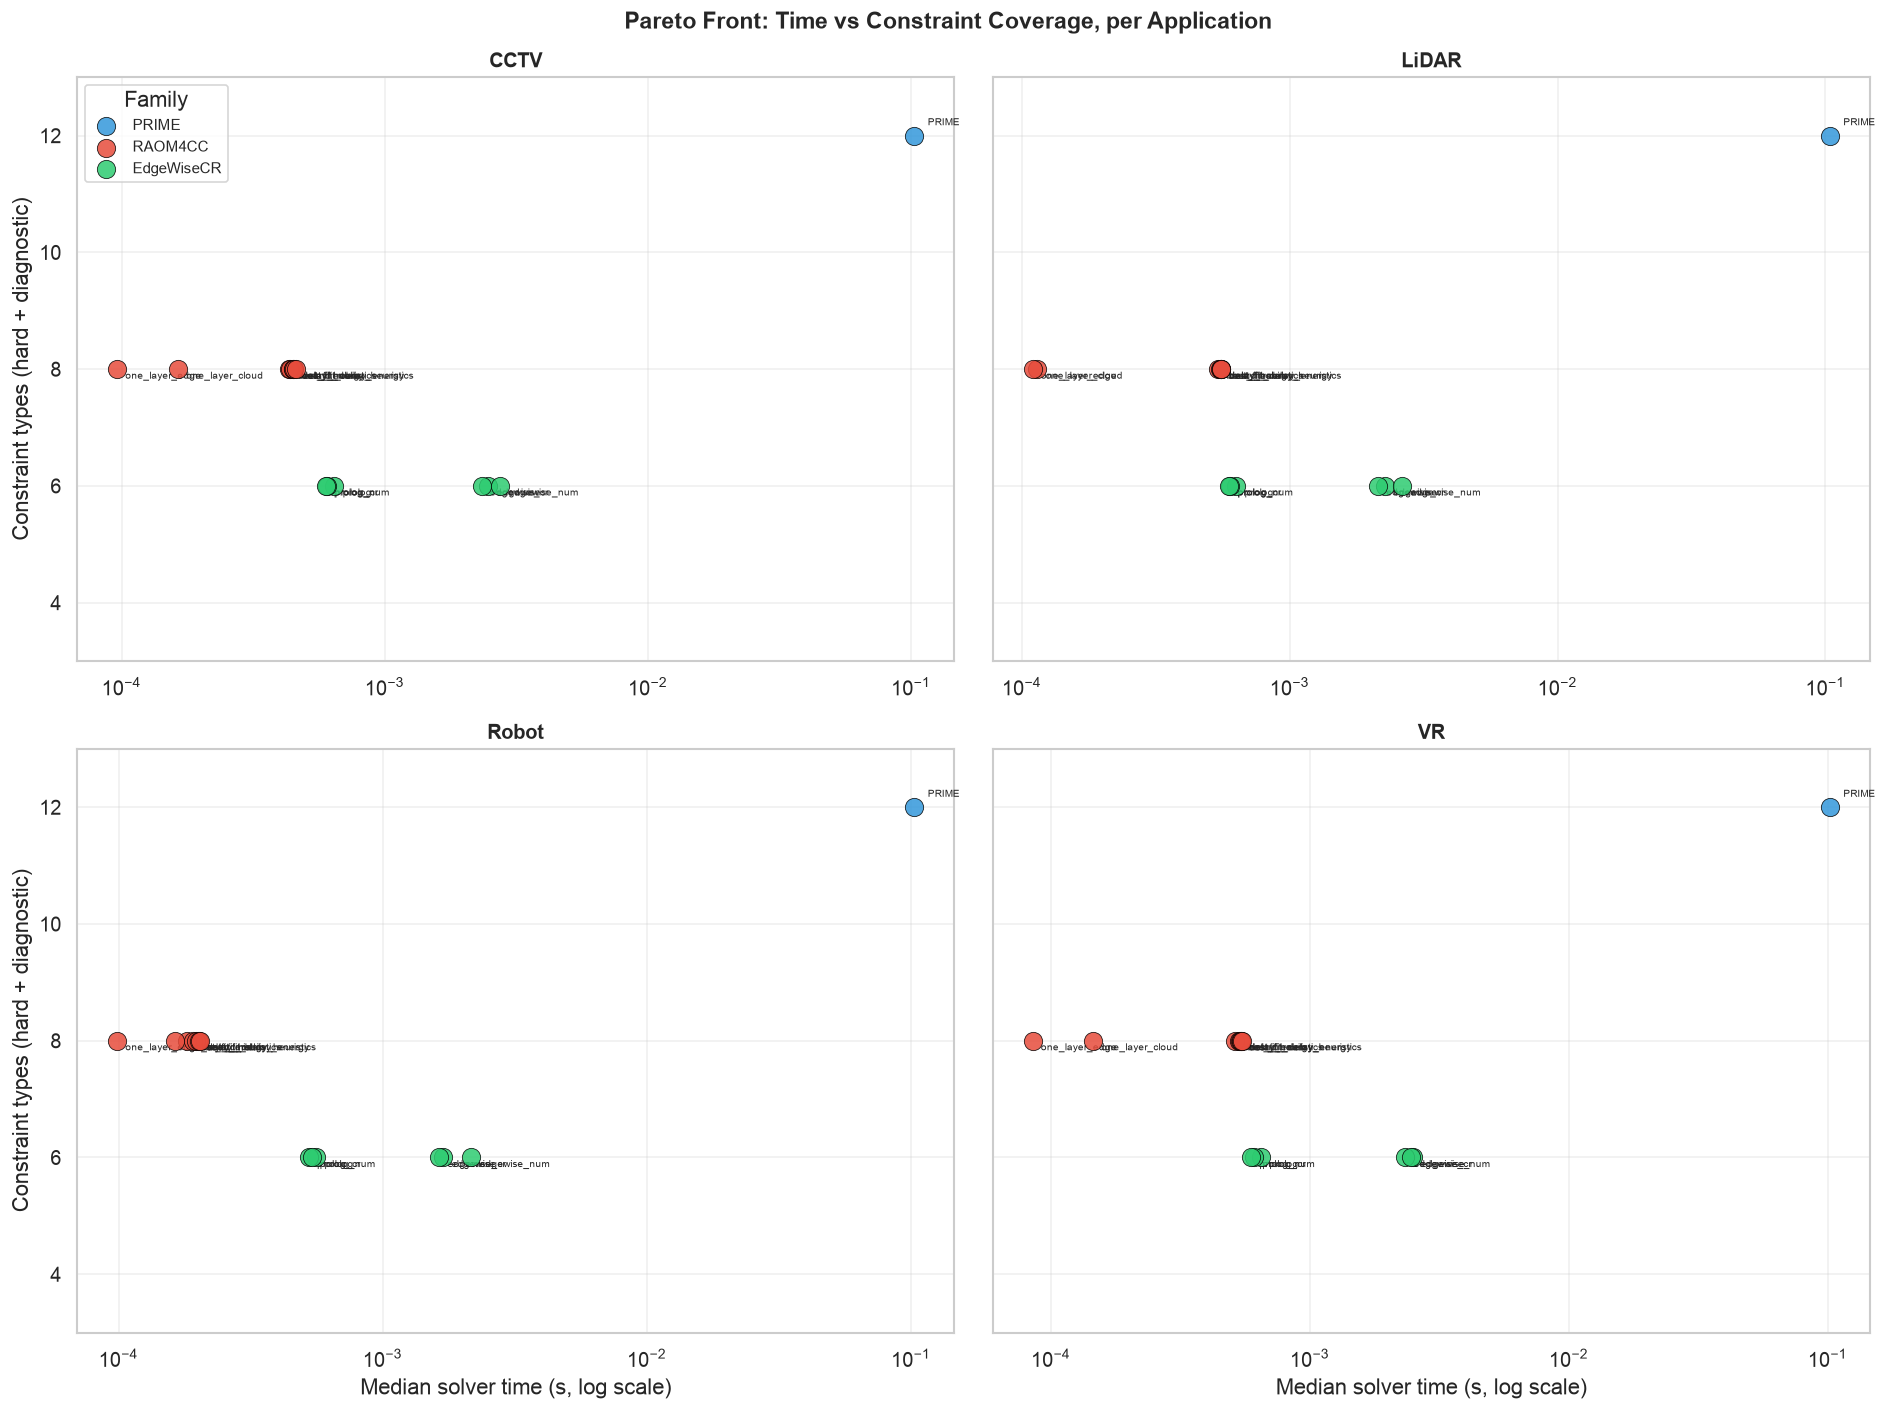

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
for ax, app in zip(axes.flat, APP_ORDER):
    sub = feasible_data[feasible_data['app'] == app]
    pareto = sub.groupby('technique').agg(
        median_time=('time_s', 'median'),
        constraints=('constraints', 'first'),
        family=('family', 'first'),
    )
    for family, color in FAMILY_COLORS.items():
        subset = pareto[pareto['family'] == family]
        ax.scatter(subset['median_time'], subset['constraints'],
                   c=color, s=120, alpha=0.85, edgecolors='black', linewidth=0.5,
                   label=family, zorder=5)
        for tech, row in subset.iterrows():
            label = tech.replace(f'{family}_', '').replace(family, '')
            if family == 'PRIME':
                label = 'PRIME'
            offset = (8, 5) if family == 'PRIME' else (5, -7)
            ax.annotate(label, (row['median_time'], row['constraints']),
                        fontsize=6, ha='left', va='bottom', xytext=offset,
                        textcoords='offset points')
    ax.set_xscale('log')
    ax.set_title(APP_NAMES[app], fontweight='bold', fontsize=12)
    if ax in [axes[1, 0], axes[1, 1]]:
        ax.set_xlabel('Median solver time (s, log scale)')
    if ax in [axes[0, 0], axes[1, 0]]:
        ax.set_ylabel('Constraint types (hard + diagnostic)')
    ax.set_ylim(3, 13)
    if ax == axes[0, 0]:
        ax.legend(title='Family', loc='upper left', fontsize=9)
fig.suptitle('Pareto Front: Time vs Constraint Coverage, per Application',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/pareto_by_app.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Solution Completeness Analysis

Constraint coverage is a **structural** property of each technique family and does
not vary by application type. We include it here for completeness.

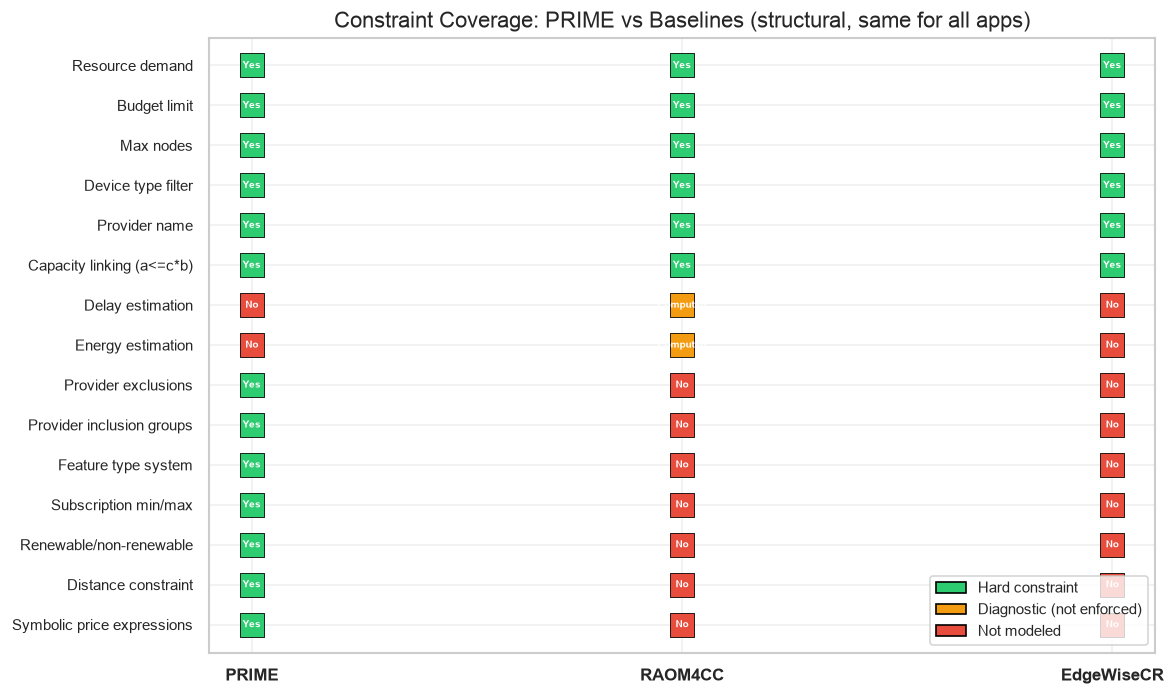

In [17]:
constraints = [
    ('Resource demand', 'hard', 'hard', 'hard'),
    ('Budget limit', 'hard', 'hard', 'hard'),
    ('Max nodes', 'hard', 'hard', 'hard'),
    ('Device type filter', 'hard', 'hard', 'hard'),
    ('Provider name', 'hard', 'hard', 'hard'),
    ('Capacity linking (a<=c*b)', 'hard', 'hard', 'hard'),
    ('Delay estimation', 'no', 'diag', 'no'),
    ('Energy estimation', 'no', 'diag', 'no'),
    ('Provider exclusions', 'hard', 'no', 'no'),
    ('Provider inclusion groups', 'hard', 'no', 'no'),
    ('Feature type system', 'hard', 'no', 'no'),
    ('Subscription min/max', 'hard', 'no', 'no'),
    ('Renewable/non-renewable', 'hard', 'no', 'no'),
    ('Distance constraint', 'hard', 'no', 'no'),
    ('Symbolic price expressions', 'hard', 'no', 'no'),
]
color_map = {'hard': '#2ecc71', 'diag': '#f39c12', 'no': '#e74c3c'}
label_map = {'hard': 'Yes', 'diag': 'Computed', 'no': 'No'}

fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, p, r, e) in enumerate(constraints):
    for j, val in enumerate([p, r, e]):
        ax.scatter(j, i, c=color_map[val], s=200, marker='s',
                   edgecolors='black', linewidth=0.5)
        ax.text(j, i, label_map[val], ha='center', va='center', fontsize=6,
                fontweight='bold', color='white')
ax.set_yticks(range(len(constraints)))
ax.set_yticklabels([c[0] for c in constraints], fontsize=9)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['PRIME', 'RAOM4CC', 'EdgeWiseCR'], fontsize=10, fontweight='bold')
ax.set_title('Constraint Coverage: PRIME vs Baselines (structural, same for all apps)')
ax.invert_yaxis()
legend_elements = [mpatches.Patch(facecolor='#2ecc71', edgecolor='black', label='Hard constraint'),
                   mpatches.Patch(facecolor='#f39c12', edgecolor='black', label='Diagnostic (not enforced)'),
                   mpatches.Patch(facecolor='#e74c3c', edgecolor='black', label='Not modeled')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('results/figures/constraint_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Findings by Application Type

In [18]:
print('=' * 90)
print('KEY FINDINGS BY APPLICATION TYPE')
print('=' * 90)

for app in APP_ORDER:
    sub_all = all_data[all_data['app'] == app]
    sub_feas = feasible_data[feasible_data['app'] == app]
    print(f'\n--- {APP_NAMES[app]} ---')

    # Feasibility
    feas_rates = sub_all.groupby('technique')['feasible'].mean() * 100
    perfect = feas_rates[feas_rates == 100].index.tolist()
    failed = feas_rates[feas_rates == 0].index.tolist()
    partial = feas_rates[(feas_rates > 0) & (feas_rates < 100)]
    print(f'  100% feasibility: {len(perfect)}/{len(feas_rates)} techniques')
    if failed:
        print(f'  0% feasibility: {failed}')
    if len(partial) > 0:
        for t, v in partial.sort_values().items():
            print(f'  Partial: {t} = {v:.1f}%')

    # PRIME time
    prime_t = sub_feas[sub_feas['technique'] == 'PRIME']['time_s']
    print(f'  PRIME time: median={prime_t.median():.3f}s, max={prime_t.max():.2f}s')
    prime_large = sub_feas[(sub_feas['technique'] == 'PRIME') & (sub_feas['scale'] == 'large')]['time_s']
    if len(prime_large) > 0:
        print(f'  PRIME large-scale: median={prime_large.median():.3f}s, max={prime_large.max():.2f}s')

    # Fastest baseline
    base_t = sub_feas[sub_feas['technique'] != 'PRIME'].groupby('technique')['time_s'].median()
    fastest = base_t.min()
    speedup = prime_t.median() / fastest
    print(f'  Fastest baseline: {fastest:.6f}s ({speedup:.0f}x faster than PRIME median)')

    # Node count
    prime_nodes = sub_feas[sub_feas['technique'] == 'PRIME']['nodes'].median()
    ew_milp_nodes = sub_feas[sub_feas['technique'].str.startswith('EdgeWiseCR_edgewise')]['nodes'].median()
    print(f'  Nodes: PRIME={prime_nodes:.0f}, EW.MILP={ew_milp_nodes:.0f}')

print(f'\n--- CROSS-APP COMPARISON ---')
print(f'PRIME max time by app (large scale):')
for app in APP_ORDER:
    sub = feasible_data[(feasible_data['app'] == app) & (feasible_data['technique'] == 'PRIME') & (feasible_data['scale'] == 'large')]
    print(f'  {APP_NAMES[app]:<8s}: median={sub["time_s"].median():.2f}s, max={sub["time_s"].max():.2f}s')

KEY FINDINGS BY APPLICATION TYPE

--- CCTV ---
  100% feasibility: 15/16 techniques
  0% feasibility: ['RAOM4CC_one_layer_mist']
  PRIME time: median=0.103s, max=8.88s
  PRIME large-scale: median=1.145s, max=8.88s
  Fastest baseline: 0.000096s (1072x faster than PRIME median)
  Nodes: PRIME=3, EW.MILP=6

--- LiDAR ---
  100% feasibility: 14/16 techniques
  0% feasibility: ['RAOM4CC_one_layer_mist']
  Partial: RAOM4CC_one_layer_cloud = 91.7%
  PRIME time: median=0.104s, max=0.67s
  PRIME large-scale: median=0.338s, max=0.66s
  Fastest baseline: 0.000110s (949x faster than PRIME median)
  Nodes: PRIME=3, EW.MILP=4

--- Robot ---
  100% feasibility: 14/16 techniques
  0% feasibility: ['RAOM4CC_one_layer_cloud']
  Partial: RAOM4CC_one_layer_mist = 83.3%
  PRIME time: median=0.103s, max=43.80s
  PRIME large-scale: median=2.882s, max=43.80s
  Fastest baseline: 0.000099s (1045x faster than PRIME median)
  Nodes: PRIME=3, EW.MILP=3

--- VR ---
  100% feasibility: 15/16 techniques
  0% feasibil

  Robot   : median=2.88s, max=43.80s
  VR      : median=5.65s, max=83.78s
